# Практика. Построение модели предсказания рейтинга отеля

### Постановка задачи

Мы работаем дата-сайентистом в компании Booking. Одна из проблем компании — это нечестные отели, которые накручивают себе рейтинг. Одним из способов обнаружения таких отелей является построение модели, которая предсказывает рейтинг отеля. Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель ведёт себя нечестно, и его стоит проверить. Нам поставлена задача создать такую модель.

### Цель проекта

Провести разведочный анализ данных (EDA), выполнить генерацию и преобразование признаков и построить базовую модель машинного обучения для предсказания рейтинга отеля.

### Метрика качества

Результаты оцениваются по метрике MAPE. Файл представления Для каждого **id** отеля в наборе тестовых данных должны предсказать рейтинг отеля для **reviewer_score** переменной. Файл должен содержать заголовок и иметь следующий формат: ``` reviewer_score,id 1,1 ```

### Данные
* [hotels.csv](https://drive.google.com/file/d/1Qj0iYEbD64eVAaaBylJeIi3qvMzxf2C_/view?usp=sharing) - датасет с отзывами на отели Европы
* [ссылка](https://www.kaggle.com/competitions/sf-booking/data) на соревнование на Kaggle 
* файлы с Kaggle:
    * hotels_train.csv - набор данных для обучения
    * hotels_test.csv - набор данных для оценки качества
    * submission.csv - файл сабмишна в нужном формате

### Описание данных:

| **Наименование столбца** | **Описание** |
| :--- | :--- |
| **hotel_address** | адрес отеля |
| **review_date** | дата, когда рецензент разместил соответствующий отзыв |
| **average_score** | средний балл отеля, рассчитанный на основе последнего комментария за последний год |
| **hotel_name** | название отеля |
| **reviewer_nationality** | страна рецензента |
| **negative_review** | отрицательный отзыв, который рецензент дал отелю |
| **review_total_negative_word_counts** | общее количество слов в отрицательном отзыве |
| **positive_review** | положительный отзыв, который рецензент дал отелю |
| **review_total_positive_word_counts** | общее количество слов в положительном отзыве |
| **reviewer_score** | оценка, которую рецензент поставил отелю на основе своего опыта |
| **total_number_of_reviews_reviewer_has_given** | количество отзывов, которые рецензенты дали в прошлом |
| **total_number_of_reviews** | общее количество действительных отзывов об отеле |
| **tags** | теги, которые рецензент дал отелю |
| **days_since_review** | количество дней между датой проверки и датой очистки |
| **additional_number_of_scoring** | количество действительных оценок без проверки (только баллы) |
| **lat** | географическая широта отеля |
| **lng** | географическая долгота отеля |


### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import category_encoders as ce

from sklearn.model_selection import train_test_split # инструмент для разбивки
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели 
from sklearn.feature_selection import chi2 # хи-квадрат
from sklearn.feature_selection import f_classif # anova

#%pip install geopy
from geopy.geocoders import Nominatim # для получения координат
from geopy.distance import geodesic as GD # для определения дистанции
import time

from collections import Counter
import re

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer # для анализа тональности текста
nltk.downloader.download('vader_lexicon')

import os

# Создаем папку, если её еще нет
if not os.path.exists('visualization'):
    os.makedirs('visualization')
    print("Папка 'visualization' создана!")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
Папка 'visualization' создана!


/opt/conda/lib/python3.7/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


# 1. Загрузка данных

In [2]:
RANDOM_SEED = 42

DATA_DIR = '/kaggle/input/bk-lama/' 
df_train = pd.read_csv(DATA_DIR+'/hotels_train.csv')             # датасет для обучения
df_test = pd.read_csv(DATA_DIR+'hotels_test.csv')                # датасет для предсказания
sample_submission = pd.read_csv(DATA_DIR+'/submission.csv')      # самбмишн

In [3]:
display(df_test.head(3))
display(df_test.info())

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

None

In [4]:
display(df_train.head(3))
display(df_train.info())

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

None

In [5]:
sample_submission.head(5)

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596


# 2. Обработка данных

### Проверим данные на наличие дубликатов и пропусков

Проверим тренировочный датасет на наличие дубликатов и удалим их:

In [6]:
display(f'Количество дубликатов в тренировочной выборке: {df_train[df_train.duplicated()].shape[0]}')
df_train = df_train.drop_duplicates()
display(f'Размер таблицы после удаления дубликатов: {df_train.shape}')

'Количество дубликатов в тренировочной выборке: 307'

'Размер таблицы после удаления дубликатов: (386496, 17)'

Объединим тестовую и тренировочную выборки

In [7]:
df_train['sample'] = 1           # помечаем где у нас трейн
df_test['sample'] = 0            # помечаем где у нас тест
df_test['reviewer_score'] = 0    # в тесте у нас нет значения reviewer_score, мы его должны предсказать, поэтому пока просто заполняем нулями

# Объединяем списком [test, train]
# ignore_index=True делает сквозную нумерацию от 0 до 515 737
df = pd.concat([df_test, df_train], ignore_index=True, sort=False)

print(df.info())
print(f"Форма объединенного датасета: {df.shape}")
print(df['sample'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

Проверка датасета на наличие пропусков и нулей

In [8]:
# Создаем отчет по пропускам и нулям
missing_report = pd.DataFrame({
    'NaN_count': df.isna().sum(),
    'Zeros_count': (df == 0).sum(),
    'Data_Type': df.dtypes
})
# Оставляем только те колонки, где есть хотя бы один пропуск или ноль
display(missing_report[(missing_report['NaN_count'] > 0) | (missing_report['Zeros_count'] > 0)])

,NaN_count,Zeros_count,Data_Type
review_total_negative_word_counts,0,127816,int64
review_total_positive_word_counts,0,35924,int64
lat,3268,0,float64
lng,3268,0,float64
sample,0,128935,int64
reviewer_score,0,128935,float64


В столбцах долгота и широта есть NaN, необходимо либо заменить либо заполнить координатами отелей, в столбцах review_total_positive_word_counts, review_total_negative_word_counts содержатся нули, которых необходимо заполнить. Начнём с координат избавимся от NaN. В столбце sample нули необходимы для долнейшего разделения.

Для заполнения пропущенные значений координат воспользуемся Nominatim из библиотеки geopy. Напишем функцию поиска координат по адресу или названию отеля.

In [9]:
def get_coordinates(address: str):
    geolocator = Nominatim(user_agent="hotel_address_app", timeout=10)
    try:
        location = geolocator.geocode(address)
        if location:
            return (location.latitude, location.longitude)
        else:
            return (None, None)
    except:
        return (None, None)

Пройдем по всем записям с пропусками и попытаемся найти и заполнить координаты. Если поиск по адресу не дает результата, ищем по названию отеля.

In [10]:
# Ищем уникальные адреса, где есть NaN
missing_addresses = df[df['lat'].isna()]['hotel_address'].unique()
print(f"Нужно найти координаты для {len(missing_addresses)} уникальных отелей")

# Инициализируем один раз
geolocator = Nominatim(user_agent="booking_project_fix", timeout=10)

found_coords = {}

for addr in missing_addresses:
    try:
        location = geolocator.geocode(addr)
        if location:
            found_coords[addr] = (location.latitude, location.longitude)
        time.sleep(1.1) 
    except:
        continue

# Заполняем пропуски (здесь все остается так же)
lat_map = {addr: coords[0] for addr, coords in found_coords.items()}
lng_map = {addr: coords[1] for addr, coords in found_coords.items()}

df['lat'] = df['lat'].fillna(df['hotel_address'].map(lat_map))
df['lng'] = df['lng'].fillna(df['hotel_address'].map(lng_map))


Нужно найти координаты для 17 уникальных отелей


In [11]:
coordinates_dict = {}

for index, row in df[df['lat'].isna() & df['lng'].isna()].iterrows():
    
    hotel_name = row['hotel_name']
    hotel_address = row['hotel_address']
    
    if hotel_name in coordinates_dict.keys():
        df.loc[index, 'lat'], df.loc[index, 'lng'] = coordinates_dict[hotel_name]
        continue
    
    coordinates = get_coordinates(hotel_address)       

    if pd.NA in coordinates:
        coordinates = get_coordinates(hotel_name)
        
    df.loc[index, 'lat'], df.loc[index, 'lng'] = coordinates
    coordinates_dict[hotel_name] = coordinates
    
    time.sleep(1)

print(f"Осталось пропусков: {df['lat'].isna().sum()}")


Осталось пропусков: 3268


После поиска и заполнения координат с помощью API остались записи с пропусками, для 17 отелей не удалось найти координаты. Найдем эти координаты в ручном режиме и заполним оставшеся пропуски.

In [12]:
# Создаем справочник точных координат для адресов
manual_coords = {
    'W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria': (48.2203, 16.3559),
    'Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria': (48.2204, 16.3558),
    '23 Rue Damr mont 18th arr 75018 Paris France': (48.8889, 2.3331),
    'Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria': (48.2094, 16.3534),
    'Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria': (48.2136, 16.3799),
    'Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria': (48.2108, 16.3475),
    'Bail n 4 6 Eixample 08010 Barcelona Spain': (41.3916, 2.1779),
    'Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria': (48.1888, 16.3838),
    '4 rue de la P pini re 8th arr 75008 Paris France': (48.8745, 2.3235),
    '20 Rue De La Ga t 14th arr 75014 Paris France': (48.8398, 2.3245),
    'W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria': (48.2163, 16.3601),
    'Savoyenstra e 2 16 Ottakring 1160 Vienna Austria': (48.2196, 16.2856),
    'Pau Clar s 122 Eixample 08009 Barcelona Spain': (41.3927, 2.1674),
    'Sieveringer Stra e 4 19 D bling 1190 Vienna Austria': (48.2459, 16.3418),
    'Paragonstra e 1 11 Simmering 1110 Vienna Austria': (48.1768, 16.4206),
    'Hasenauerstra e 12 19 D bling 1190 Vienna Austria': (48.2378, 16.3333),
    'Sep lveda 180 Eixample 08011 Barcelona Spain': (41.3848, 2.1609)
}

# Заполняем NaN значения точечно через .loc
for addr, coords in manual_coords.items():
    df.loc[(df['hotel_address'] == addr) & (df['lat'].isna()), 'lat'] = coords[0]
    df.loc[(df['hotel_address'] == addr) & (df['lng'].isna()), 'lng'] = coords[1]

# Финальная проверка (должен быть заветный 0!)
print(f"ИТОГО пропусков в координатах: {df['lat'].isna().sum()}")



ИТОГО пропусков в координатах: 0


Таким образом:

В результате обработки тренировочных данных найдено и удалено 307 дублирующихся записей, а также заполнили недостающие значения координат отелей для 3268 строк в объедененной выборке.

## 3. Исследование данных и генерация признаков

Вывeдем основные статистические характеристики для всех признаков

In [13]:
df.describe(include='all')

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng,sample,reviewer_score
count,515431,515431.000000,515431,515431.000000,515431,515431,515431,515431.000000,515431.000000,515431,515431.000000,515431.000000,515431,515431,515431.000000,515431.000000,515431.00000,515431.000000
unique,1493,NaN,731,NaN,1492,227,330011,NaN,NaN,412601,NaN,NaN,55242,731,NaN,NaN,NaN,NaN
top,163 Marsh Wall Docklands Tower Hamlets London ...,NaN,8/2/2017,NaN,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,NaN,NaN,No Positive,NaN,NaN,"[' Leisure trip ', ' Couple ', ' Double Room '...",1 days,NaN,NaN,NaN,NaN
freq,4789,NaN,2584,NaN,4789,245165,127816,NaN,NaN,35924,NaN,NaN,5101,2584,NaN,NaN,NaN,NaN
mean,NaN,498.275079,NaN,8.397630,NaN,NaN,NaN,18.539760,2744.259084,NaN,17.777342,7.165215,NaN,NaN,49.432744,2.893769,0.74985,6.296715
std,NaN,500.618961,NaN,0.548033,NaN,NaN,NaN,29.690973,2317.823718,NaN,21.803204,11.038742,NaN,NaN,3.461232,4.668785,0.43310,3.902967
min,NaN,1.000000,NaN,5.200000,NaN,NaN,NaN,0.000000,43.000000,NaN,0.000000,1.000000,NaN,NaN,41.328376,-0.369758,0.00000,0.000000
25%,NaN,169.000000,NaN,8.100000,NaN,NaN,NaN,2.000000,1161.000000,NaN,5.000000,1.000000,NaN,NaN,48.214066,-0.143372,0.00000,0.000000
50%,NaN,342.000000,NaN,8.400000,NaN,NaN,NaN,9.000000,2134.000000,NaN,11.000000,3.000000,NaN,NaN,51.499981,0.019886,1.00000,7.900000
75%,NaN,660.000000,NaN,8.800000,NaN,NaN,NaN,23.000000,3633.000000,NaN,22.000000,8.000000,NaN,NaN,51.516288,4.841163,1.00000,9.600000


3.1 Признак **hotel_address** - адрес отеля

Признаке 'hotel_address' содержится информация о городе и стране отеля. Извлечем эту информацию. Возможно, есть связь между городом\страной отеля и его оценкой.

In [14]:
def get_hotel_city(value: str):
    word_arr = value.split()
    return word_arr[-5] if word_arr[-2].strip()=='United' else word_arr[-2]

def get_hotel_country(value: str):
    word_arr = value.split()
    return word_arr[-2]+' '+word_arr[-1] if word_arr[-2].strip()=='United' else word_arr[-1]

# Применяем функции к основному датафрейму
df['hotel_city'] = df['hotel_address'].apply(get_hotel_city)
df['hotel_country'] = df['hotel_address'].apply(get_hotel_country)


Выведем все страны и города, а также посмотрим на количество оценок по городам

In [15]:
display(f"Уникальные города: {df['hotel_city'].unique()}")
display(f"Уникальные страны: {df['hotel_country'].unique()}")

display(df.groupby(by=['hotel_country','hotel_city'], observed=True)['hotel_country'].agg('count').to_frame('rating_count').reset_index())

"Уникальные города: ['Milan' 'Amsterdam' 'Barcelona' 'London' 'Paris' 'Vienna']"

"Уникальные страны: ['Italy' 'Netherlands' 'Spain' 'United Kingdom' 'France' 'Austria']"

,hotel_country,hotel_city,rating_count
0,Austria,Vienna,38938
1,France,Paris,59626
2,Italy,Milan,37206
3,Netherlands,Amsterdam,57212
4,Spain,Barcelona,60149
5,United Kingdom,London,262300


Как видно из таблицы, больше всего rating_count для отелей Лондона.

Построим график зависимости медианы оценки отеля от города:

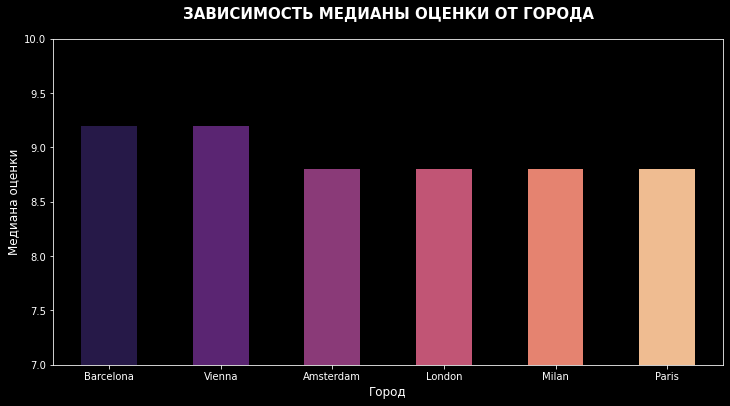

In [16]:
# Подготовка данных
bar_data = df[df['sample'] == 1].groupby('hotel_city', observed=True)['reviewer_score'].agg('median').sort_values(ascending=False).reset_index()

# УСТАНАВЛИВАЕМ ТЕМНЫЙ ФОН
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

# Строим график
plot = sns.barplot(
    data=bar_data, x='hotel_city', y='reviewer_score', 
    hue='hotel_city', palette='magma', dodge=False
)

# Цикл для стройности столбиков
new_width = 0.5
for bar in plot.patches:
    x = bar.get_x()
    w = bar.get_width()
    centre = x + w / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

plt.ylim(7, 10)
plt.title('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ ГОРОДА', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)
plt.legend([], frameon=False)


plt.savefig('visualization/hotel_city_median_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

plt.style.use('default')


Таким образом:

Из признака 'hotel_address' выделили два признака 'hotel_country' и 'hotel_city'. Медиана оценки отеля выше (9.2) для отелей Барселоны и Вены, для остальных городов медиана равна 8.8. Так как для каждой страны представлены данные только для одного города, при отборе признаков выберем либо город, либо страну отеля.

3.2 Признак **review_date** - дата, когда рецензент разместил соответствующий отзыв. Возможно сезонность играет роль при выставлении оценки отелю. Выделим из даты оценки признак месяца и сезона.

In [17]:
# Убедимся, что дата в формате datetime
df['review_date'] = pd.to_datetime(df['review_date'])

# Создаем месяц 
df['review_month'] = df['review_date'].dt.month

# Функция для сезонов (исправили sommer на summer)
def get_season_fast(month):
    if 3 <= month <= 5: return 'spring'
    if 6 <= month <= 8: return 'summer'
    if 9 <= month <= 11: return 'autumn'
    return 'winter'

# Создаем колонку с сезоном
df['review_season'] = df['review_month'].apply(get_season_fast)

# Сразу переводим сезоны в числа для Леса, чтобы не было ошибок потом
df['review_season'] = df['review_season'].factorize()[0]

print("Влияние сезона на оценку:")
print(df[df['sample']==1].groupby('review_season')['reviewer_score'].median())



Влияние сезона на оценку:
review_season
0    8.8
1    9.2
2    8.8
3    8.8
Name: reviewer_score, dtype: float64


Исследуем сезонность: как меняется медианный балл оценки отеля в зависимости от месяца и времени года

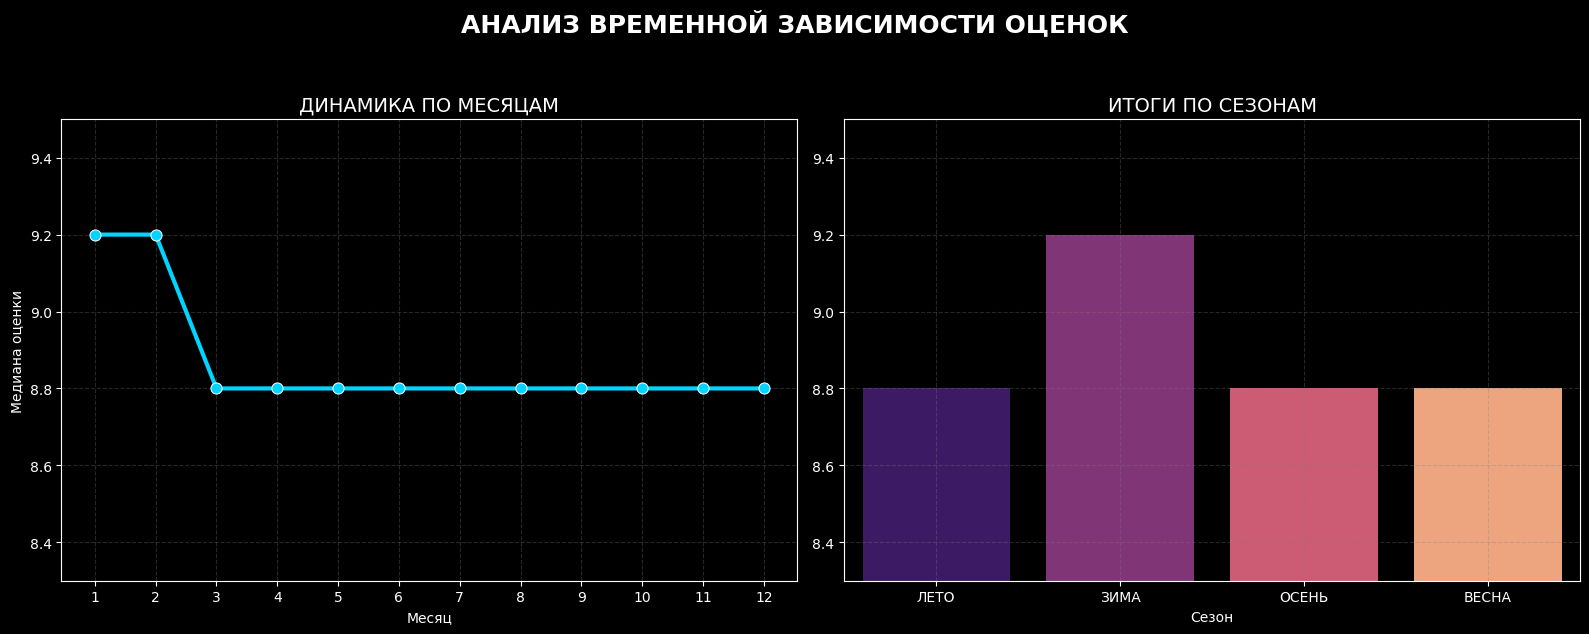

In [18]:
# Подготовка данных (твоя логика без изменений)
month_data = df[df['sample']==1].groupby('review_month')['reviewer_score'].median().reset_index()
season_data = df[df['sample']==1].groupby('review_season')['reviewer_score'].median().reset_index()
season_names = {0: 'ЛЕТО', 1: 'ЗИМА', 2: 'ОСЕНЬ', 3: 'ВЕСНА'}
season_data['season_name'] = season_data['review_season'].map(season_names)

# УСТАНАВЛИВАЕМ ТЕМНЫЙ СТИЛЬ
plt.style.use('dark_background') # Это сделает фон черным
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('АНАЛИЗ ВРЕМЕННОЙ ЗАВИСИМОСТИ ОЦЕНОК', fontsize=18, y=1.05, fontweight='bold')

# ГРАФИК 1: Динамика по месяцам ---
sns.lineplot(
    data=month_data, x='review_month', y='reviewer_score', 
    marker='o', color='#00d4ff', linewidth=3, markersize=8, ax=axes[0]
)
axes[0].set_title('ДИНАМИКА ПО МЕСЯЦАМ', fontsize=14)
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Медиана оценки')
axes[0].set_ylim(8.3, 9.5)
axes[0].set_xticks(range(1, 13))
axes[0].grid(color='gray', linestyle='--', alpha=0.3) # Деликатная сетка

# ГРАФИК 2: Итоги по сезонам
sns.barplot(
    data=season_data, x='season_name', y='reviewer_score', 
    hue='season_name', palette='magma', dodge=False, ax=axes[1]
)
axes[1].set_title('ИТОГИ ПО СЕЗОНАМ', fontsize=14)
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('') 
axes[1].set_ylim(8.3, 9.5)
axes[1].legend([], frameon=False) 
axes[1].grid(color='gray', linestyle='--', alpha=0.3)

# 3. Сохранение графики
plt.tight_layout()
plt.savefig('visualization/combined_time_analysis_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возвращаем стандарт, чтобы не влиять на следующие ячейки
plt.style.use('default')


Как очевидно из **fig_time_combined**

Из признака даты оценки 'review_date' выделили признак сезоны года 'review_season' и месяца оценки 'review_month'. Как видно из графиков, медиана оценки выше зимой (январь - февраль) и составляет 9.2, в остальные месяцы медиана равна 8.8. Эти признаки пригодятся нам при построении модели. На этапе отбора признаков проверим силу связи 'review_season' и 'review_month', возможно один из признаков нужно будет удалить.

#### 3.3 Признак **average_score** - средний балл отеля, рассчитанный на основе последнего комментария за последний год

Средний балл отеля может влиять на выставление оценки. Построим график зависимости оценки от среднего балла отеля, дополнительно окрасим данные по сезону.


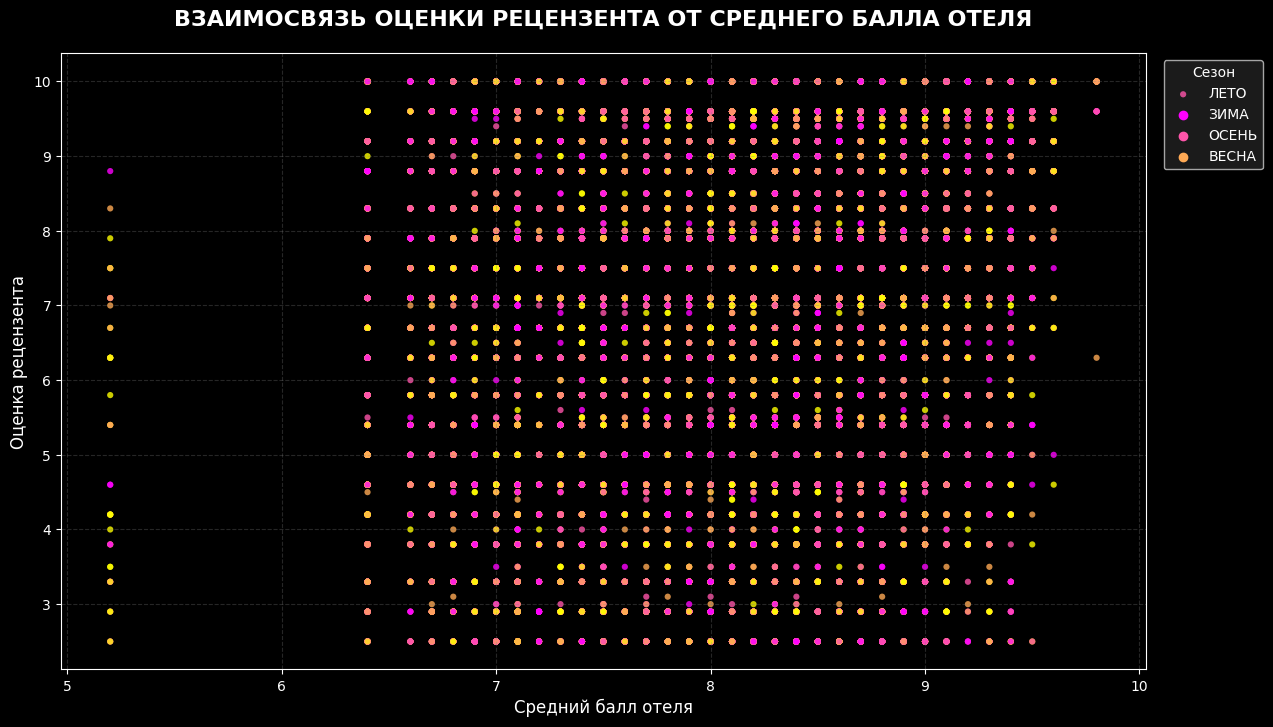

In [19]:
# Устанавливаем общую темную фон
plt.style.use('dark_background') 
plt.figure(figsize=(14, 8))

# 2. Строим график
scatter_plot = sns.scatterplot(
    data=df[df['sample'] == 1],
    x='average_score',
    y='reviewer_score',
    hue='review_season',
    palette='spring', 
    alpha=0.8,        # Высокая плотность цвета
    s=20,             # Крупные точки
    edgecolor='none',    
    linewidth=0.5
)

# Настройка сетки (чтобы она не была слишком яркой)
plt.grid(color='gray', linestyle='--', alpha=0.3)

# Заголовок и подписи
plt.title('ВЗАИМОСВЯЗЬ ОЦЕНКИ РЕЦЕНЗЕНТА ОТ СРЕДНЕГО БАЛЛА ОТЕЛЯ', 
          fontsize=16, pad=20, color='white', fontweight='bold')
plt.xlabel('Средний балл отеля', fontsize=12, color='white')
plt.ylabel('Оценка рецензента', fontsize=12, color='white')

# Легенда
season_labels = ['ЛЕТО', 'ЗИМА', 'ОСЕНЬ', 'ВЕСНА']
plt.legend(labels=season_labels, title='Сезон', bbox_to_anchor=(1.01, 1), 
           loc='upper left', frameon=True, facecolor='#222222')

plt.savefig('visualization/average_score_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возвращаем стандартную тему для следующих графиков, чтобы не всё было черным
plt.style.use('default')



#### Итак:

Большой разброс точек (дисперсия) доказывает, что оценка — это не математика, а эмоции. Один и тот же отель может получить и 4, и 10. Если бы все точки лежали на одной линии, то можно было бы скопировать средний балл отеля. Только из графика сложно вывести взаимосвязь оценки рецензента от среднего балла отеля, дополнительно проверим значимость признака на этапе отбора.

#### 3.4 Признак **hotel_name** - название отеля

Из описательной статистики видим, что в выборке 1492 уникальных значений признака. Этот признак не будет участвовать в построении модели. Визуальный анализ проводить не будем.

#### 3.5 Признак **reviewer_nationality** - страна рецензента

Из описательной статистики видим, что в выборке 227 стран рецензента, больше всего из United Kingdom. Предположим, что страна рецензента влияет на оценку отеля, а также имеет значение, оценивает рецензент отель из своей страны или другой.

Выберем Топ-10 стран рецензентов, оставшиеся объединим в группу 'Other', создадим признак 'reviewer_nationality_grouped'. Для информации об оценке внутри страны создадим признак 'is_local_resident'.

In [20]:
display(f"Количество уникальных стран рецензентов: {df['reviewer_nationality'].nunique()}")

# Выделяем ТОП-10
top_10_reviewer_countries = df['reviewer_nationality'].value_counts().head(10).index.tolist()
display(top_10_reviewer_countries)


'Количество уникальных стран рецензентов: 227'

[' United Kingdom ',
 ' United States of America ',
 ' Australia ',
 ' Ireland ',
 ' United Arab Emirates ',
 ' Saudi Arabia ',
 ' Netherlands ',
 ' Switzerland ',
 ' Germany ',
 ' Canada ']

In [21]:
def apply_local_resident(hotel_country: str, reviewer_nationality: str):
    # Убираем лишние пробелы 
    return 1 if str(hotel_country).strip() == str(reviewer_nationality).strip() else 0

df['is_local_resident'] = df.apply(
    lambda x: apply_local_resident(x.hotel_country, x.reviewer_nationality), 
    axis=1
)
# Группируем национальности по top_10_reviewer_countries)
df['reviewer_nationality_grouped'] = df['reviewer_nationality'].apply(
    lambda x: x if x in top_10_reviewer_countries else 'Other'
)
# Проверяем результат
display(df['is_local_resident'].value_counts())
display(df['reviewer_nationality_grouped'].value_counts())



0    337047
1    178384
Name: is_local_resident, dtype: int64

 United Kingdom               245165
Other                         145961
 United States of America      35390
 Australia                     21663
 Ireland                       14820
 United Arab Emirates          10230
 Saudi Arabia                   8945
 Netherlands                    8762
 Switzerland                    8672
 Germany                        7936
 Canada                         7887
Name: reviewer_nationality_grouped, dtype: int64

Построим график зависимости медианы оценки отеля от страны рецензента:

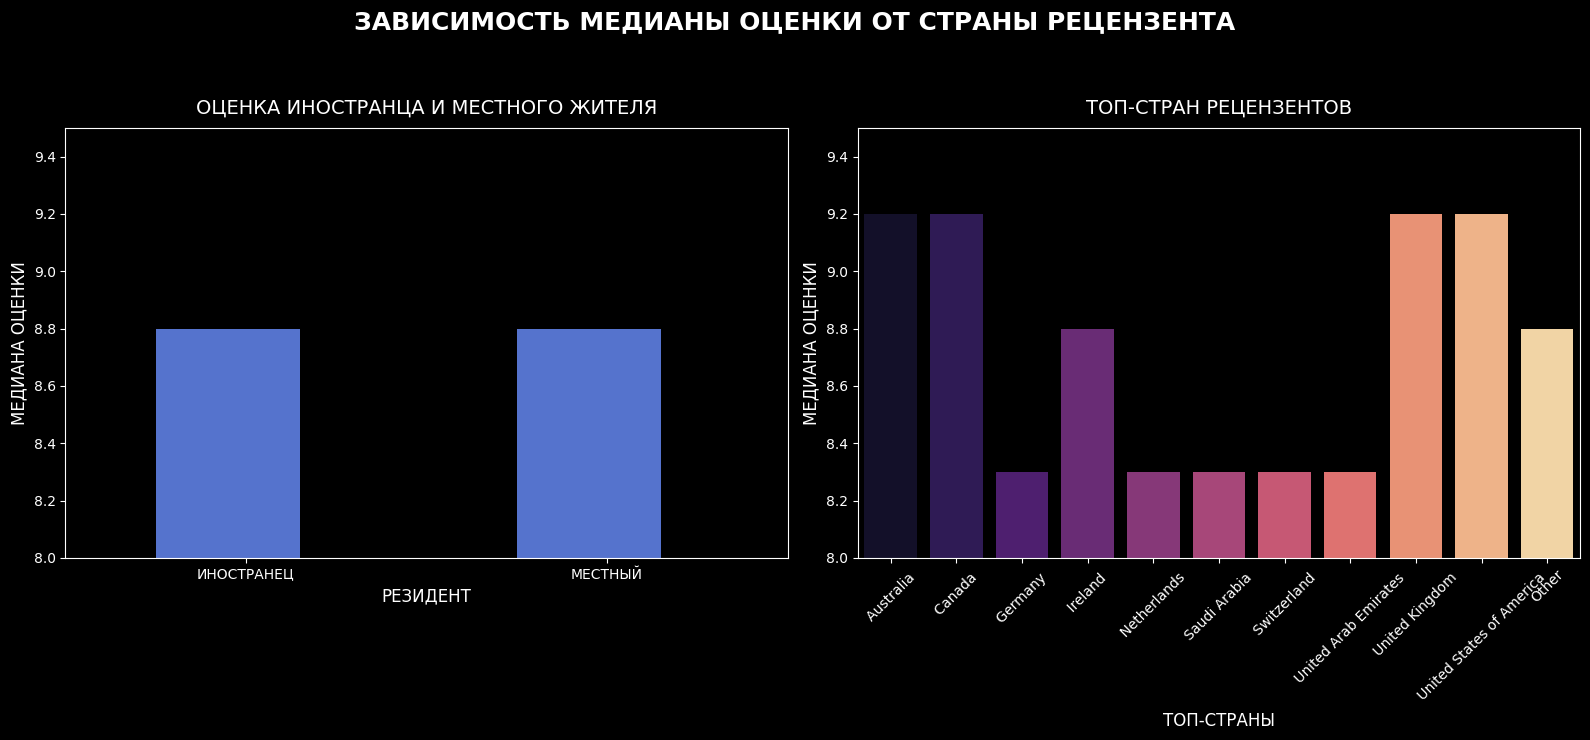

In [22]:
# Подготовка данных
bar_data_is_local_resident = df[df['sample']==1].groupby(by='is_local_resident', observed=True)['reviewer_score'].agg('median').reset_index()
bar_data_nationality_grouped = df[df['sample']==1].groupby(by='reviewer_nationality_grouped', observed=True)['reviewer_score'].agg('median').reset_index()

# Заменяем 0 и 1 на текст для графика
resident_map = {0: 'ИНОСТРАНЕЦ', 1: 'МЕСТНЫЙ'}
bar_data_is_local_resident['is_local_resident'] = bar_data_is_local_resident['is_local_resident'].map(resident_map)

# Настройка стиля (Темный фон)
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ СТРАНЫ РЕЦЕНЗЕНТА', fontsize=18, y=1.05, fontweight='bold')

# ГРАФИК 1: Иностранец vs Местный
plot1 = sns.barplot(
    data=bar_data_is_local_resident, 
    x='is_local_resident', 
    y='reviewer_score', 
    # Убираем hue, чтобы столбики встали по центру
    color='royalblue', # Выберем один сочный цвет для обоих или зададим палитру ниже
    ax=axes[0]
)

# Вручную меняем ширину каждого столбика после построения
for bar in axes[0].patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    
    bar.set_width(0.4) # Устанавливаем ширину 0.4
    bar.set_x(centre - 0.5 / 2.) # Центрируем обратно

axes[0].set_title('ОЦЕНКА ИНОСТРАНЦА И МЕСТНОГО ЖИТЕЛЯ', fontsize=14, pad=10)
axes[0].set_ylim(8.0, 9.5)
axes[0].set_xlabel('РЕЗИДЕНТ', fontsize=12)
axes[0].set_ylabel('МЕДИАНА ОЦЕНКИ', fontsize=12)
axes[0].legend([], frameon=False)

# ГРАФИК 2: ТОП стран 
sns.barplot(
    data=bar_data_nationality_grouped, 
    x='reviewer_nationality_grouped', 
    y='reviewer_score', 
    hue='reviewer_nationality_grouped',
    palette='magma', 
    dodge=False,
    ax=axes[1]
)
axes[1].set_title('ТОП-СТРАН РЕЦЕНЗЕНТОВ', fontsize=14, pad=10)
axes[1].set_xlabel('ТОП-СТРАНЫ', fontsize=12)
axes[1].set_ylabel('МЕДИАНА ОЦЕНКИ', fontsize=12)
axes[1].set_ylim(8.0, 9.5)
axes[1].legend([], frameon=False)

# Делаем подписи стран под наклоном, если их много
plt.setp(axes[1].get_xticklabels(), rotation=45)

# 3. Сохранение
plt.tight_layout()
plt.savefig('visualization/reviewer_nationality_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возвращаем стандартную тему
plt.style.use('default')


####  Таким образом:

Из признака страны рецензента reviewer_nationality сформированы маркеры is_local_resident и агрегированный признак reviewer_nationality_grouped, в котором редко встречающиеся страны объединены в общую группу. Визуальный анализ распределения оценок показал отсутствие значимой зависимости медианного балла от статуса резидента (местный/иностранец). При этом выявлены различия в лояльности по странам: наиболее высокие оценки характерны для представителей United Kingdom, United States of America, Australia и Canada (медиана — 9.2). Более строгие оценки наблюдаются у респондентов из ОАЭ, Саудовской Аравии, Нидерландов, Швейцарии и Германии. Значимость данных факторов будет окончательно подтверждена на этапе оценки важности признаков (Feature Importance

#### 3.6 Признак **negative_review** - отрицательный отзыв, который рецензент дал отелю

Вероятнее всего, признак негативного отзыва будет непосредственно влиять на оценку отеля, как отмечалось выше оценка - это эмоции, воспользуемся NLP для анализа данных. 

Из описательной статистики признака видим, что самое распространенное значение признака "No Negative" и оно не является негативным. Посмотрим на часто встречающиеся отзывы и выберем те, которые не имеют негативного окраса.

In [23]:
display(df['negative_review'].value_counts().head(10))

No Negative    127816
 Nothing        14291
 Nothing         4234
 nothing         2223
 N A             1037
 None             984
                  849
 N a              509
 Breakfast        407
 Small room       373
Name: negative_review, dtype: int64

Как очевидно из данных, часто встречающихся значенияий признака, следует, что есть ряд слов и предложений, которые не содержат негативный отзыв. Соответственно, создадим новый признак 'is_negative_review', который будет указывать, действительно ли оценка содержит негативный отзыв.

In [24]:
#  Список слов-пустышек 
not_negative_words = [
    'no negative', 'nothing', 'n a', 'na', 'n/a', 'none', '' ,'nil',
    'all good', 'no complaints', 'nothing to dislike', 'everything was perfect',
    'everything was great', 'can t think of anything', 'cant think of anything', 
    "can't think of anything", 'nothing at all'
]

def check_negative_review(review: str):
    # Чистим пробелы, переводим в нижний регистр и проверяем в списке
    return 0 if str(review).strip().lower() in not_negative_words else 1

df['is_negative_review'] = df['negative_review'].apply(check_negative_review)

# Сразу расшифровываем детали негатива
neg_keywords = ['location', 'staff', 'breakfast', 'view', 'bed', 'clean']

for word in neg_keywords:
    # Ищем слово только если это реальный негатив (is_negative_review == 1)
    df[f'neg_{word}'] = df.apply(
        lambda x: 1 if (x['is_negative_review'] == 1 and word in str(x['negative_review']).lower()) else 0, 
        axis=1
    )

print("Признаки негатива")
display(df[[f'neg_{k}' for k in neg_keywords]].sum())


Признаки негатива


neg_location     10932
neg_staff        34906
neg_breakfast    50072
neg_view         10187
neg_bed          37137
neg_clean        17566
dtype: int64

Дополнительно воспользуемся SentimentIntensityAnalyzer из библиотеки nltk для анализа тональности отзыва.

In [25]:
sentiment = SentimentIntensityAnalyzer()

# Считаем скоры для негативных отзывов
df['negative_scores'] = df['negative_review'].apply(sentiment.polarity_scores)

# Раскладываем по колонкам
df['negative_sentiments_neg'] = df['negative_scores'].apply(lambda x: x['neg'])
df['negative_sentiments_neu'] = df['negative_scores'].apply(lambda x: x['neu'])
df['negative_sentiments_pos'] = df['negative_scores'].apply(lambda x: x['pos'])
df['negative_sentiments_compound'] = df['negative_scores'].apply(lambda x: x['compound'])

# удаляем служебную колонку-словарь
df.drop(['negative_scores'], axis=1, inplace=True)


Визуализируем зависимость медианы оценки отелей от нового признака 'is_negative_review':

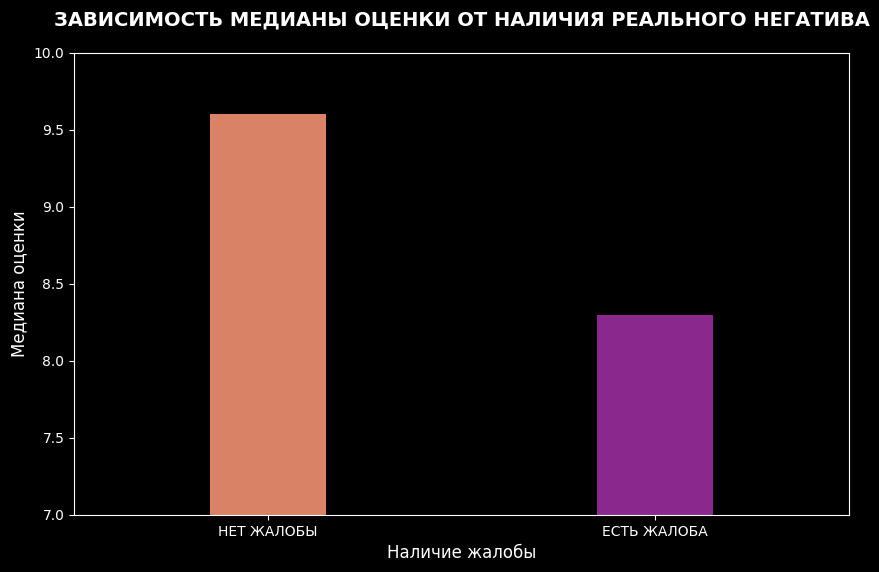

In [26]:
# Подготовка данных
bar_data_neg = df[df['sample'] == 1].groupby(
    by='is_negative_review', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Заменяем 0 и 1 на красивый текст
neg_map = {0: 'НЕТ ЖАЛОБЫ', 1: 'ЕСТЬ ЖАЛОБА'}
bar_data_neg['is_negative_review'] = bar_data_neg['is_negative_review'].map(neg_map)

# 2. Настройка стиля
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Строим график
# Используем палитру 'plasma' для эффекта "неона"
plot = sns.barplot(
    data=bar_data_neg,
    x='is_negative_review',
    y='reviewer_score',
    hue='reviewer_score',
    palette='plasma',
    dodge=False
)

# Делаем столбики узкими 
new_width = 0.3
for bar in plot.patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# Настройки осей и заголовка
plt.ylim(7.0, 10.0) # Твой диапазон
plt.title('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ НАЛИЧИЯ РЕАЛЬНОГО НЕГАТИВА', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Наличие жалобы', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)
plt.legend([], frameon=False) # Убираем лишнюю легенду

# Сохранение
plt.savefig('visualization/is_negative_review_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к дефолтной теме
plt.style.use('default')




Из fig_is_neg очевидно, а так же исследования признака 'negative_review',выявлено, что не все негативные отзывы являются действительно негативными. В связи этим, создали новый признак 'is_negative_review', который указывает на то, является ли отзыв негативным. Оказалось более 30% отзывов не являются негативными. Как видно из графика зависимости медианы оценки отеля от признака 'is_negative_review' у действительно негативных отзывов медиана оценки ниже (8.3), так же провели анализ тональности отзывов.

#### 3.7 Признак **review_total_negative_word_counts** - общее количество слов в отрицательном отзыве

Можно предположить, что чем больше слов в отрицательном отзыве, тем он более эмоциональный и соответственно оценка ниже. Построим график зависимости медианы оценки от количества слов в отрицательном отзыве.

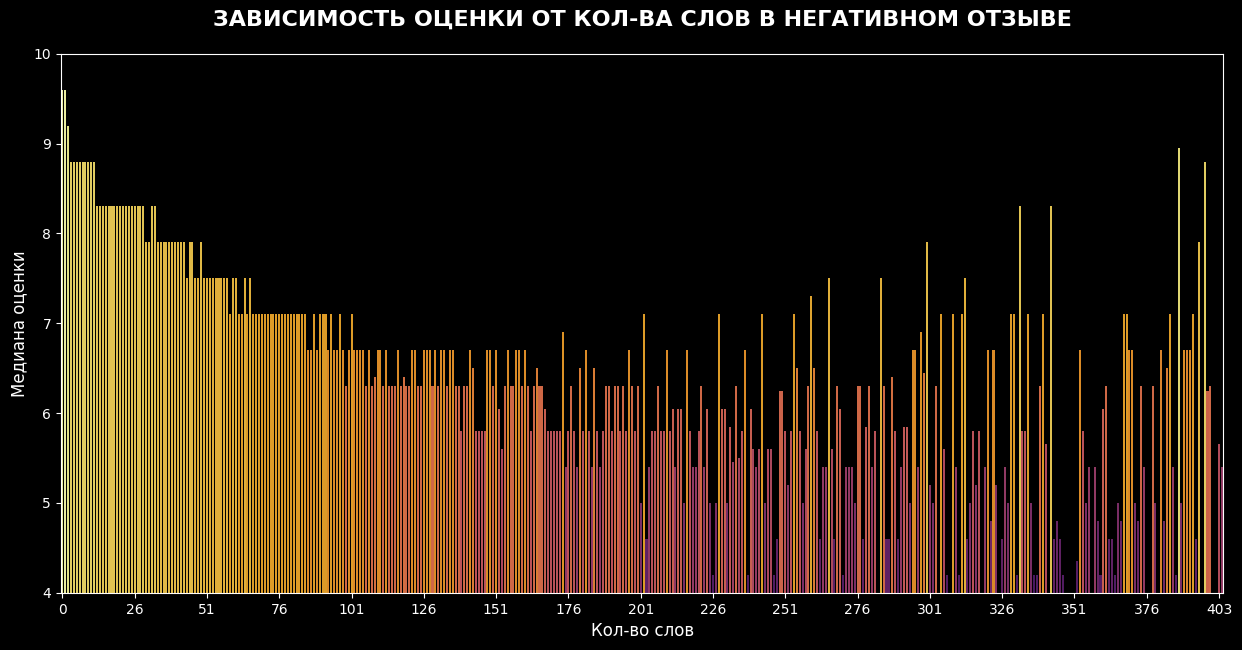

In [27]:
# Подготовка данных
grouped_neg_words = df[df['sample'] == 1].groupby(
    'review_total_negative_word_counts', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Настройка темного стиля
plt.style.use('dark_background')
plt.figure(figsize=(15, 7))

# Строим график
# Используем палитру 'inferno', чтобы падение оценки выглядело эффектно
plot = sns.barplot(
    data=grouped_neg_words,
    x='review_total_negative_word_counts',
    y='reviewer_score',
    hue='reviewer_score',
    palette='inferno',
    dodge=False
)

# Регулируем ширину столбиков 
new_width = 0.7 
for bar in plot.patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# 5. Настройки осей (сужаем диапазон по твоему совету — от 4 до 10)
plt.ylim(4, 10)
plt.title('ЗАВИСИМОСТЬ ОЦЕНКИ ОТ КОЛ-ВА СЛОВ В НЕГАТИВНОМ ОТЗЫВЕ', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Кол-во слов', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)

# Убираем лишние подписи на оси X, если их слишком много (шаг 5)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=20))

plt.legend([], frameon=False, loc='upper right') 

plt.savefig('visualization/neg_word_counts_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')




Таким образом:

Как видно из fig_neg_words, действительно, чем больше слов в негативном отзыве, тем медиана оценки отеля меньше. Данный признак будет полезен для правильной тренировки модели.

#### 3.8 Признак **positive_review** - положительный отзыв, который рецензент дал отелю

Из описательной статистики признака видим, что самым распространенное значением является "No Positive" и оно не является позитивным. Посмотрим на часто встречающиеся отзывы и выберем те, которые не имеют позитивного окраса.

In [28]:
display(df['positive_review'].value_counts().head(10))

No Positive        35924
 Location           9213
 Everything         2284
 location           1674
 Nothing            1242
 The location       1124
 Great location     1045
 Good location       927
 Location            915
 Everything          613
Name: positive_review, dtype: int64

Как и с негативным отзывом, не все значения признака 'positive_review' имеют положительный окрас. Определим какое значение действительно является положительным, а какое нет. Для этого создадим новый признак 'is_positive_review'.

In [29]:
# Список слов-пустышек для позитива 
not_positive_words = ['no positive', 'nothing', 'n a', 'none', '', 'nil']

# Базовый флаг: есть ли реальный текст похвалы
df['is_positive_review'] = df['positive_review'].apply(
    lambda x: 0 if str(x).strip().lower() in not_positive_words else 1
)

# Ищем конкретные "плюсы" (Keywords Spotting)
pos_keywords = ['location', 'staff', 'breakfast', 'view', 'bed', 'clean']

for word in pos_keywords:
    # Ищем слово только если это реальный позитив (is_positive_review == 1)
    df[f'pos_{word}'] = df.apply(
        lambda x: 1 if (x['is_positive_review'] == 1 and word in str(x['positive_review']).lower()) else 0, 
        axis=1
    )

print("Признаки позитива созданы!")
display(df[[f'pos_{k}' for k in pos_keywords]].sum().sort_values(ascending=False))


Признаки позитива созданы!


pos_location     189406
pos_staff        189379
pos_breakfast     82617
pos_clean         74193
pos_bed           66906
pos_view          22281
dtype: int64

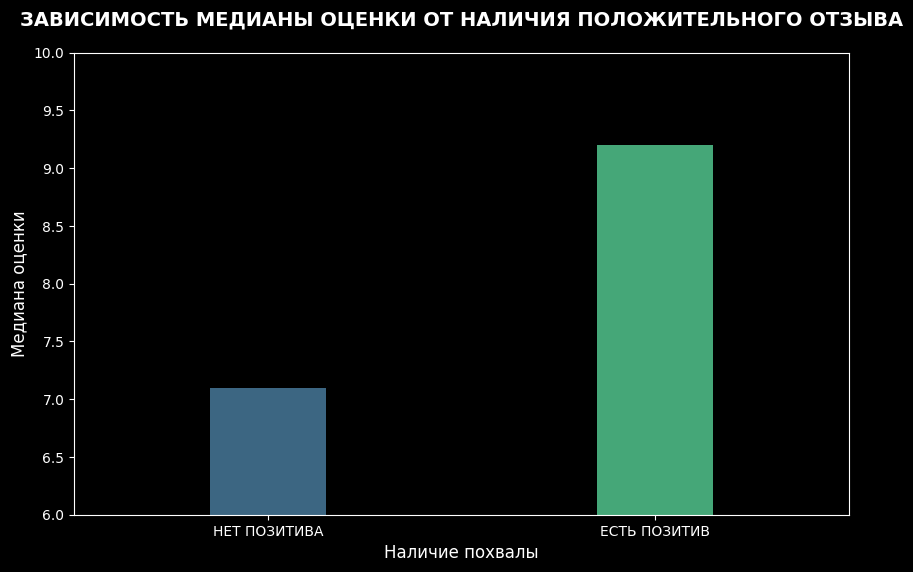

In [30]:
# Подготовка данных
bar_data_pos = df[df['sample'] == 1].groupby(
    by='is_positive_review', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Заменяем 0 и 1 на понятный текст
pos_map = {0: 'НЕТ ПОЗИТИВА', 1: 'ЕСТЬ ПОЗИТИВ'}
bar_data_pos['is_positive_review'] = bar_data_pos['is_positive_review'].map(pos_map)

# Настройка стиля
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# 3. Строим график
# 'viridis' даст приятный переход от фиолетового к желто-зеленому
plot = sns.barplot(
    data=bar_data_pos,
    x='is_positive_review',
    y='reviewer_score',
    hue='reviewer_score',
    palette='viridis',
    dodge=False
)

# Делаем столбики стройными (width=0.3)
new_width = 0.3
for bar in plot.patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# Настройки осей (диапазон от 6 до 10)
plt.ylim(6.0, 10.0)
plt.title('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ НАЛИЧИЯ ПОЛОЖИТЕЛЬНОГО ОТЗЫВА', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Наличие похвалы', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)
plt.legend([], frameon=False, loc='upper right') # Добавили loc, чтобы не было Warning

# Сохранение
plt.savefig('visualization/is_positive_review_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')



Дополнительно воспользуемся SentimentIntensityAnalyzer из библиотеки nltk для анализа тональности отзыва.

In [31]:
sentiment = SentimentIntensityAnalyzer()

df['positive_scores'] = df['positive_review'].apply(sentiment.polarity_scores)

df['positive_sentiments_neg'] = df['positive_scores'].apply(lambda x: x['neg'])
df['positive_sentiments_neu'] = df['positive_scores'].apply(lambda x: x['neu'])
df['positive_sentiments_pos'] = df['positive_scores'].apply(lambda x: x['pos'])
df['positive_sentiments_compound'] = df['positive_scores'].apply(lambda x: x['compound'])

# удаляем служебную колонку-словарь
df.drop(['positive_scores'], axis=1, inplace=True)

Таким образом:

Исследование признака 'positive_review', показало, что не все позитивные отзывы являются действительно позитивными. В связи чем, создн новый признак 'is_positive_review', который указывает на то, является ли отзыв положительным. Оказалось около 8% отзывов не являются положительными. Как видно из графика зависимости медианы оценки отеля от признака 'is_positive_review' у действительно положительных отзывов медиана оценки выше (9.2), чем у "ложно" положительных (7.1). Дополнительно провели анализ тональности отзывов.

#### 3.9 Признак **review_total_positive_word_counts** - общее количество слов в положительном отзыве

Можно предположить, что чем больше слов в положительном отзыве, тем он более эмоциональный и соответственно оценка выше. Построим график зависимости медианы оценки от количества слов в положительном отзыве.

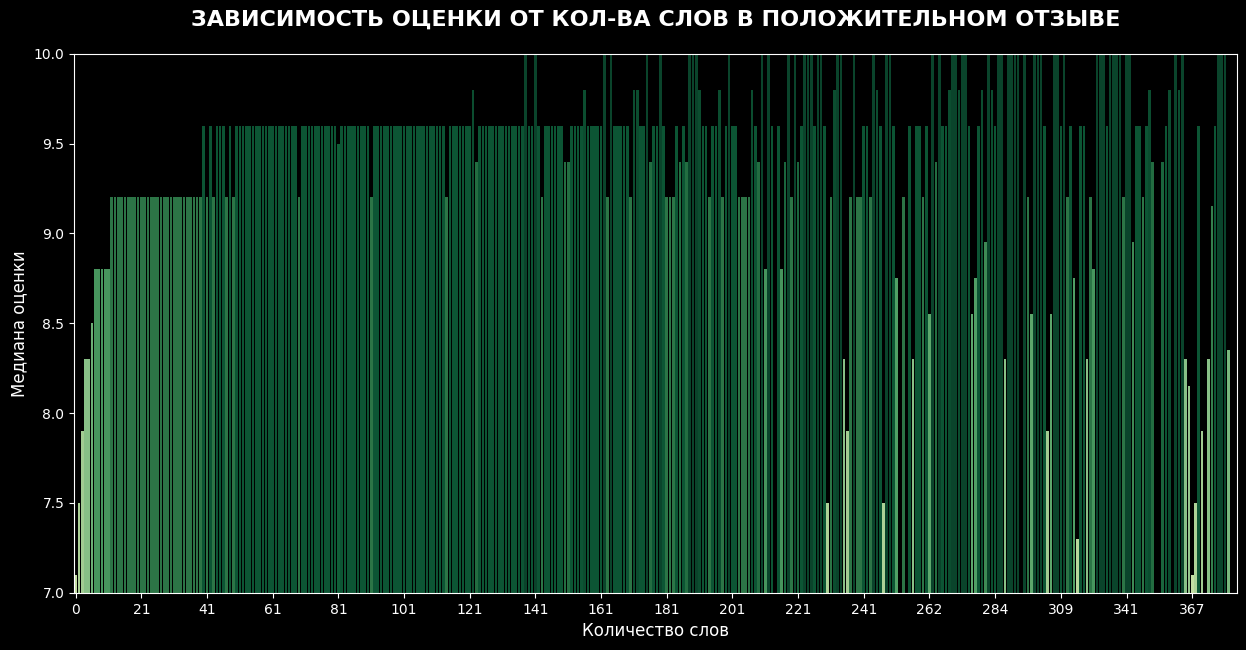

In [32]:
# Подготовка данных
grouped_pos_words = df[df['sample'] == 1].groupby(
    'review_total_positive_word_counts', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Настройка стиля
plt.style.use('dark_background')
plt.figure(figsize=(15, 7))

# Строим график
# Используем палитру 'Wistia' или 'YlGn', чтобы график "светился" позитивом
plot = sns.barplot(
    data=grouped_pos_words,
    x='review_total_positive_word_counts',
    y='reviewer_score',
    hue='reviewer_score',
    palette='YlGn', # От желтого к сочному зеленому
    dodge=False
)

# Регулируем ширину столбиков (делаем их плотными, но раздельными)
new_width = 0.8 
for bar in plot.patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# Настройки осей (диапазон от 7 до 10, как в твоем Plotly)
plt.ylim(7, 10)
plt.title('ЗАВИСИМОСТЬ ОЦЕНКИ ОТ КОЛ-ВА СЛОВ В ПОЛОЖИТЕЛЬНОМ ОТЗЫВЕ', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Количество слов', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)

# Убираем лишние подписи на оси X для чистоты (оставляем каждую 5-ю или 10-ю)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=20))

# Подавляем легенду и предупреждение о скорости
plt.legend([], frameon=False, loc='upper right')

# Сохранение
plt.savefig('visualization/pos_word_counts_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')



Итак:

Как видно из графика, действительно, чем больше слов в положительном отзыве, тем медиана оценки отеля больше. Данный признак будет полезен для правильной тренировки модели.

#### 3.10 Признак **total_number_of_reviews_reviewer_has_given** - количество отзывов, которые рецензенты дали в прошлом

Посмотрим как влияет количество отзывов на оценку

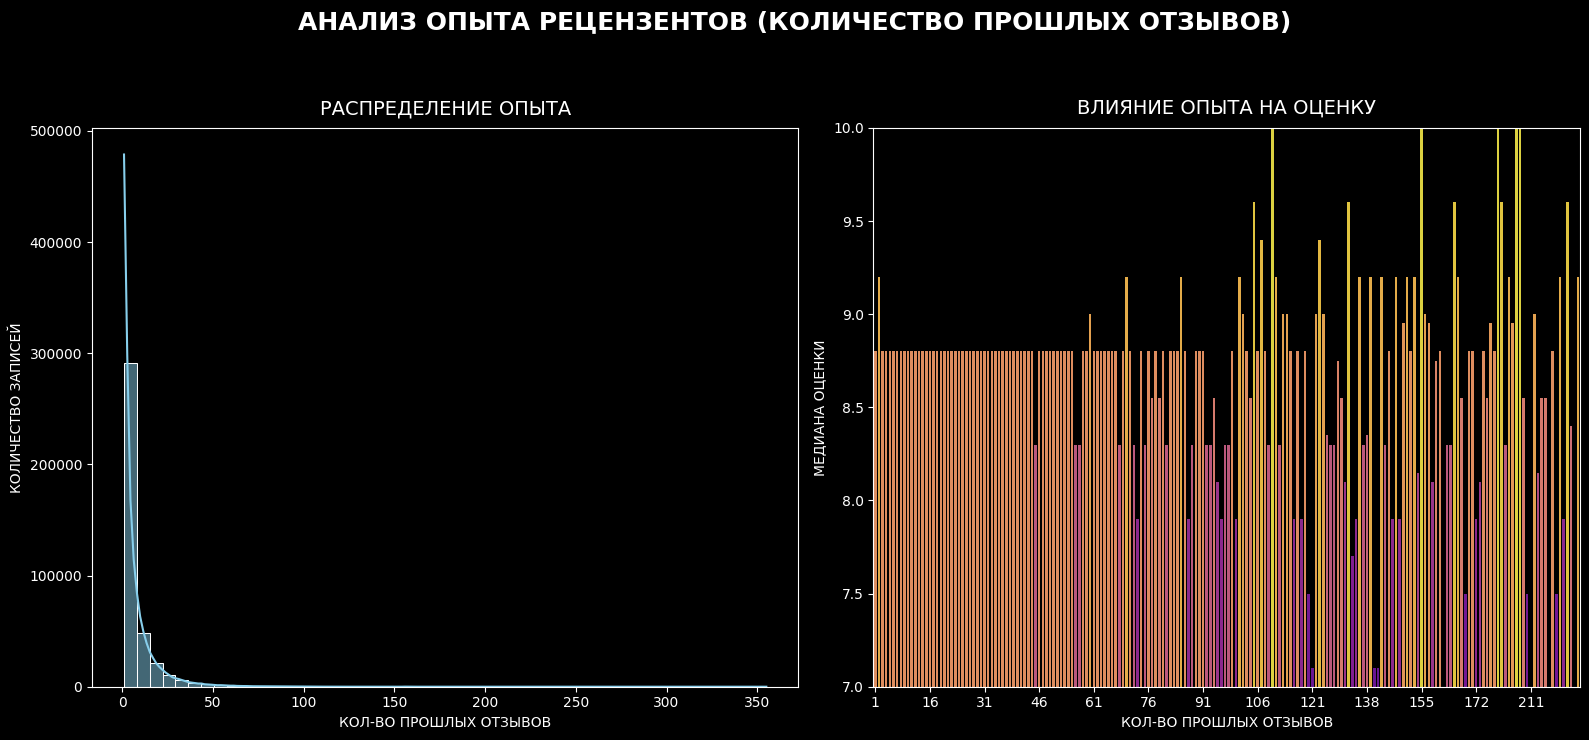

In [33]:
# Подготовка данных
train_df = df[df['sample'] == 1]
grouped_experience = train_df.groupby(
    'total_number_of_reviews_reviewer_has_given', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Настройка стиля
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('АНАЛИЗ ОПЫТА РЕЦЕНЗЕНТОВ (КОЛИЧЕСТВО ПРОШЛЫХ ОТЗЫВОВ)', fontsize=18, y=1.05, fontweight='bold')

# ГРАФИК 1: Распределение опыта (Histogram)
sns.histplot(
    data=train_df, x='total_number_of_reviews_reviewer_has_given', 
    bins=50, color='skyblue', kde=True, ax=axes[0]
)
axes[0].set_title('РАСПРЕДЕЛЕНИЕ ОПЫТА', fontsize=14, pad=10)
axes[0].set_xlabel('КОЛ-ВО ПРОШЛЫХ ОТЗЫВОВ')
axes[0].set_ylabel('КОЛИЧЕСТВО ЗАПИСЕЙ')

# ГРАФИК 2: Влияние опыта на оценку (Bar)
sns.barplot(
    data=grouped_experience, x='total_number_of_reviews_reviewer_has_given', 
    y='reviewer_score', hue='reviewer_score', palette='plasma', dodge=False, ax=axes[1]
)
# Делаем столбики чуть стройнее
new_width = 0.7
for bar in axes[1].patches:
    x = bar.get_x()
    w = bar.get_width()
    centre = x + w / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

axes[1].set_title('ВЛИЯНИЕ ОПЫТА НА ОЦЕНКУ', fontsize=14, pad=10)
axes[1].set_xlabel('КОЛ-ВО ПРОШЛЫХ ОТЗЫВОВ')
axes[1].set_ylabel('МЕДИАНА ОЦЕНКИ')
axes[1].set_ylim(7.0, 10.0) # Твой диапазон
axes[1].legend([], frameon=False, loc='upper right')


axes[1].xaxis.set_major_locator(plt.MaxNLocator(nbins=15))

# Сохранение
plt.tight_layout()
plt.savefig('visualization/reviewer_experience_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')



Далее:
Как видно из графиков у большинства рецензентов до 10 отзывов. Количество отзывов практически не влияет на оценку отеля. Перепроверим это на этапе отбора признаков.

#### 3.11 Признак **total_number_of_reviews** - общее количество действительных отзывов об отеле

Предположим, что чем меньше отзывов у отеля, тем он моложе, а соответственно имеет более свежий интерьер и работает на свою репутацию. У таких отелей оценка может оказаться выше.

Посмотрим, как влияет количество отзывов об отеле на оценку отеля.

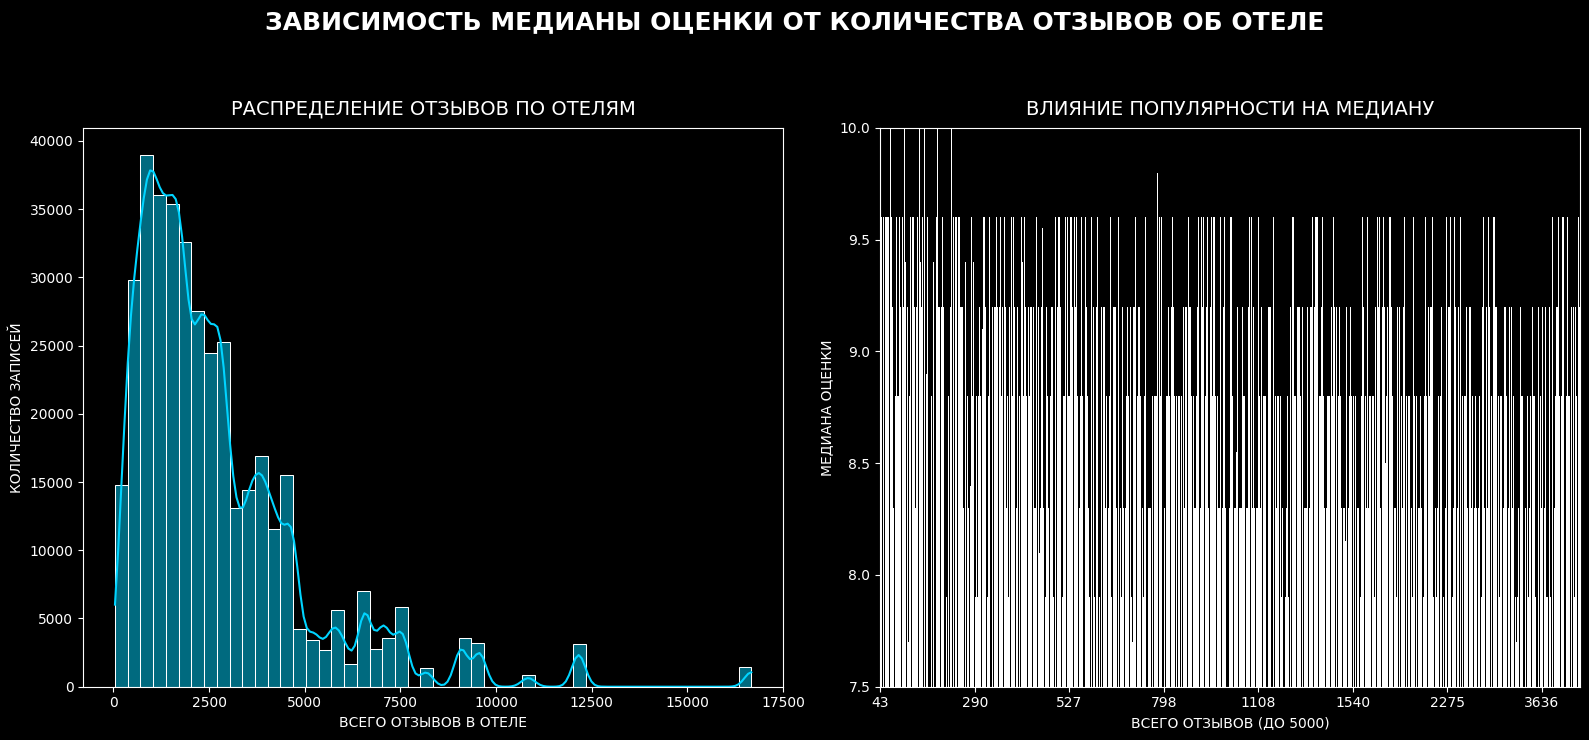

In [34]:
# Подготовка данных (сохраняем твою логику фильтрации)
train_data = df[df['sample'] == 1]
grouped_hotel_pop = train_data[train_data['total_number_of_reviews'] < 5000].groupby(
    'total_number_of_reviews', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Настройка стиля
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ КОЛИЧЕСТВА ОТЗЫВОВ ОБ ОТЕЛЕ', 
             fontsize=18, y=1.05, fontweight='bold')

# ГРАФИК 1: Распределение отзывов (Histogram)
sns.histplot(
    data=train_data, x='total_number_of_reviews', 
    bins=50, color='#00d4ff', kde=True, ax=axes[0]
)
axes[0].set_title('РАСПРЕДЕЛЕНИЕ ОТЗЫВОВ ПО ОТЕЛЯМ', fontsize=14, pad=10)
axes[0].set_xlabel('ВСЕГО ОТЗЫВОВ В ОТЕЛЕ')
axes[0].set_ylabel('КОЛИЧЕСТВО ЗАПИСЕЙ')

# ГРАФИК 2: Влияние популярности на медиану (Bar) 
sns.barplot(
    data=grouped_hotel_pop, x='total_number_of_reviews', 
    y='reviewer_score', color='#FFFFFF', ax=axes[1] # Белый цвет, как ты хотел
)

# Оптимизация оси X для правого графика 
axes[1].xaxis.set_major_locator(plt.MaxNLocator(nbins=10))

axes[1].set_title('ВЛИЯНИЕ ПОПУЛЯРНОСТИ НА МЕДИАНУ', fontsize=14, pad=10)
axes[1].set_xlabel('ВСЕГО ОТЗЫВОВ (ДО 5000)')
axes[1].set_ylabel('МЕДИАНА ОЦЕНКИ')
axes[1].set_ylim(7.5, 10.0) 

# 3. Сохранение
plt.tight_layout()
plt.savefig('visualization/hotel_popularity_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')


Итак:

Большинство отелей имеют до 5000 отзывов. Визуально трудно подтвердить предположение о влиянии признака 'total_number_of_reviews', посмотрим на значимость признака на этапе отбора.

#### 3.12 Признак **tags** - теги, которые рецензент дал отелю
Из признака 'tags' можно получить много полезной информации для построения модели.

Выведем общее количество тегов и частоту их использования.

In [35]:
df.tags = df.tags.apply(lambda x: x[3:-3].split(" ', ' "))
tags = list(df.tags.explode().value_counts())

display(f'Количество тегов: {len(tags)}')

tags_frequency = pd.Series(Counter(tags)).sort_values(ascending=False)
display(tags_frequency.head(10))

'Количество тегов: 2428'

1     197
2     177
3     131
4      92
7      83
5      75
8      74
6      74
9      66
10     53
dtype: int64

Количество уникальных тегов равно 2428. Среди значений есть тег, который указывает на сколько ночей останавливался посититель. Используя регулярные выражения, создадим тег 'stayed_nights'.

In [36]:
import re

# Функция для вытягивания количества ночей (Stayed X nights)
def get_nights(tags_list):
    for tag in tags_list:
        if 'stayed' in tag.lower():
            res = re.findall(r'\d+', tag)
            return int(res[0]) if res else 1
    return 1

# Функция для определения состава группы
def get_group_type(tags_list):
    tag_str = ' '.join(tags_list).lower()
    if 'couple' in tag_str: return 'couple'
    if 'family' in tag_str: return 'family'
    if 'solo' in tag_str: return 'solo'
    if 'group' in tag_str: return 'group'
    return 'other'

# ПРИМЕНЯЕМ:
df['stayed_nights'] = df['tags'].apply(get_nights)
df['group_type'] = df['tags'].apply(get_group_type)

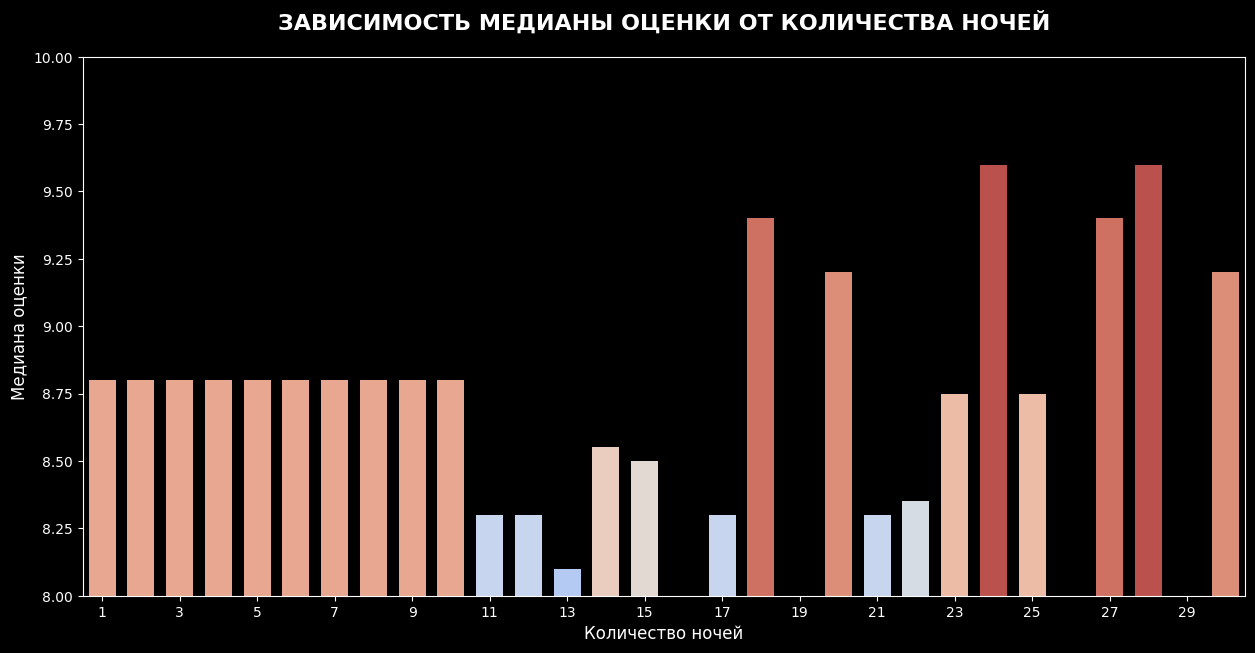

In [37]:
# Подготовка данных
bar_data_nights = df[df['sample'] == 1].groupby(
    by='stayed_nights', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# 2. Настройка темного стиля
plt.style.use('dark_background')
plt.figure(figsize=(15, 7))

# Строим график
# Палитра 'viridis' или 'coolwarm' отлично покажет динамику
plot = sns.barplot(
    data=bar_data_nights,
    x='stayed_nights',
    y='reviewer_score',
    hue='reviewer_score',
    palette='coolwarm',
    dodge=False
)

# Регулируем ширину столбиков 
new_width = 0.7 
for bar in plot.patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# Настройки осей (диапазон 8.0 - 10 как в твоем оригинале)
plt.ylim(8.0, 10)
plt.title('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ КОЛИЧЕСТВА НОЧЕЙ', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Количество ночей', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)

# Убираем легенду и лишние подписи X, если ночей слишком много
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=20))
plt.legend([], frameon=False, loc='upper right')

# 6. Сохранение
plt.savefig('visualization/stayed_nights_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')


Большинство поситителей останавливается на 1-2 ночи. Из графика не видно взаимосвязи между количеством ночей и оценкой отеля.

Возможно, отдыхающие поситители более позитивно настроены и их оценка отеля выше, чем у поситителей в бизнес-поездке. Определим тип поездки и создадим признак 'trip_type'. Если в тегах встречается слово 'business', то считаем это рабочей поездкой, если 'couple' ,'family', 'leisure' - отдыхом. Если же не удалось установить рабочую поездку или отдых, то такие записи заполним значением 'other'.

In [38]:
def get_trip_type(tags_list):
    # Превращаем список ['tag1', 'tag2'] в одну строку 'tag1 tag2'
    full_string = " ".join(tags_list).lower()
    
    if 'business' in full_string:
        return 'business'
    elif any(item in full_string for item in ['couple', 'family', 'leisure']):
        return 'leisure'
    else:
        return 'other'

# Применяем функцию
df['trip_type'] = df['tags'].apply(get_trip_type)

print(df['trip_type'].value_counts())



leisure     425744
business     83761
other         5926
Name: trip_type, dtype: int64


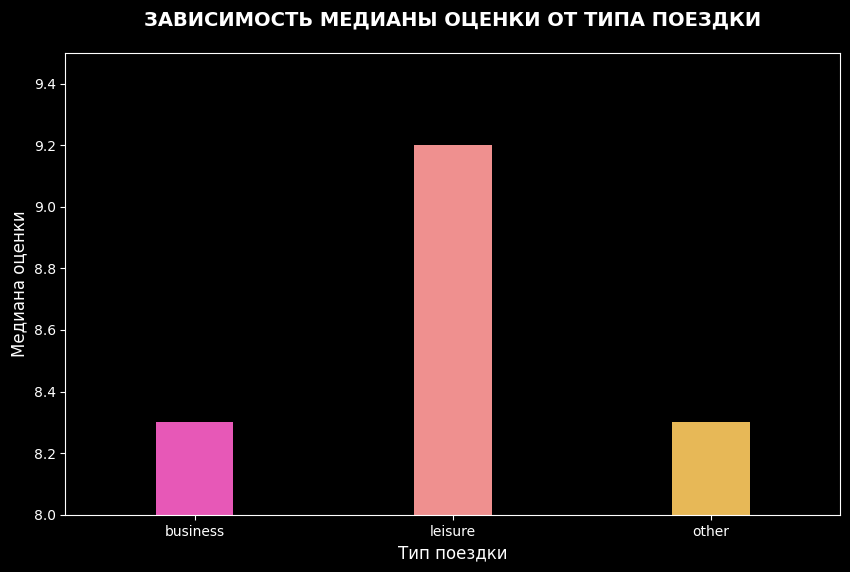

In [39]:
# Подготовка данных
bar_data_trip = df[df['sample'] == 1].groupby(
    by='trip_type', 
    observed=True
)['reviewer_score'].agg('median').reset_index()

# Настройка стиля (Темный фон)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Строим график
# 'spring' или 'cool' палитры дадут яркие неоновые цвета
plot = sns.barplot(
    data=bar_data_trip,
    x='trip_type',
    y='reviewer_score',
    hue='trip_type',
    palette='spring', 
    dodge=False
)

# Регулируем ширину столбиков (width=0.3 как в твоем Plotly)
new_width = 0.3
for bar in plot.patches:
    x = bar.get_x()
    width = bar.get_width()
    centre = x + width / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# Настройки осей (диапазон 8.0 - 9.5)
plt.ylim(8.0, 9.5)
plt.title('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ ТИПА ПОЕЗДКИ', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Тип поездки', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)
plt.legend([], frameon=False)

# 6. Сохранение
plt.savefig('visualization/trip_type_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')



Медиана оценки отеля выже у отдыхающих поситителей.

Определим тип аппартаментов, чтоб проследить взаимосвязь оценки отеля от типа номера, создадим признак 'room_type'.

In [40]:
room_types = ['without Window', 'Guestroom', 'Classic', 'Single', 'Standard', 'Superior', 'Comfort', 'Club', 'Suite', 'Deluxe', 'King', 'Premier']

def get_room_type(tags_value: str):
    for type in room_types:
        if type in tags_value:
            return type

    if 'Double' in tags_value or 'Twin' in tags_value:
        return 'Double'
    
    return 'Other'

df['room_type'] = df['tags'].apply(get_room_type)

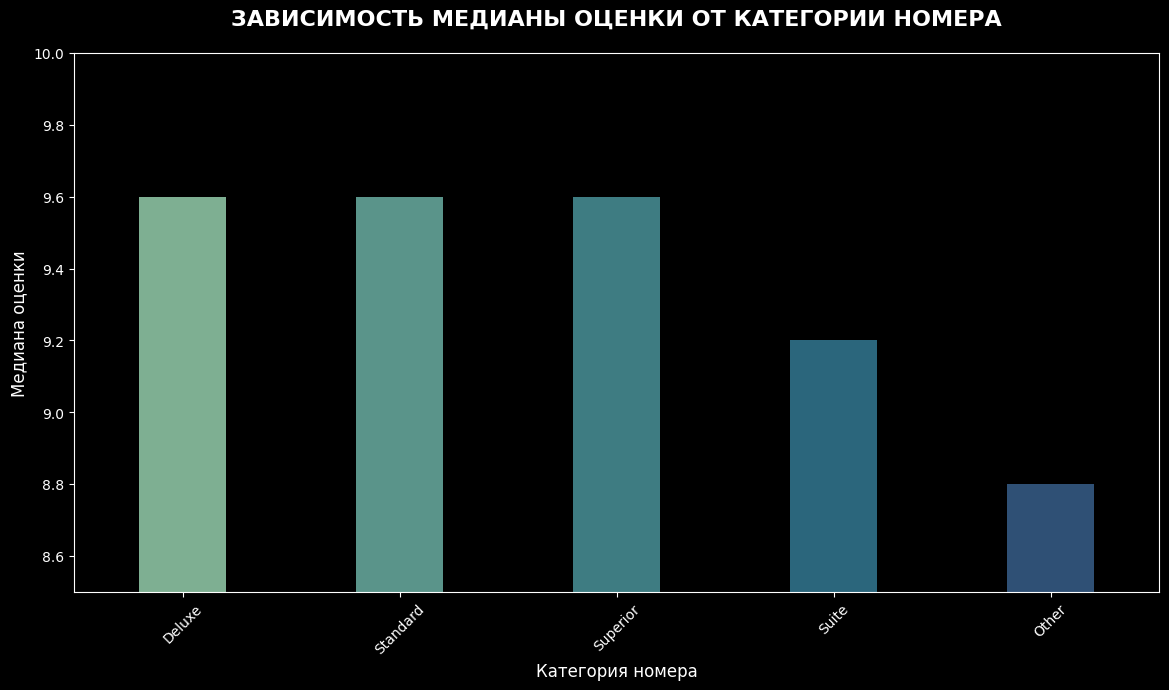

In [41]:
# Подготовка данных (сохраняем твою логику)
# Сортируем данные сразу
bar_data_room = df[df['sample'] == 1].groupby(
    by='room_type', 
    observed=True
)['reviewer_score'].agg('median').sort_values(ascending=False).reset_index()

# Настройка стиля
plt.style.use('dark_background')
plt.figure(figsize=(14, 7))

# Строим график
plot = sns.barplot(
    data=bar_data_room,
    x='room_type',
    y='reviewer_score',
    hue='room_type',
    palette='crest', # Красивый переход от бирюзового к синему
    dodge=False
)

# Делаем столбики стройными 
new_width = 0.4
for bar in plot.patches:
    x = bar.get_x()
    w = bar.get_width()
    centre = x + w / 2.
    bar.set_width(new_width)
    bar.set_x(centre - new_width / 2.)

# Настройки осей и заголовка
plt.ylim(8.5, 10)
plt.title('ЗАВИСИМОСТЬ МЕДИАНЫ ОЦЕНКИ ОТ КАТЕГОРИИ НОМЕРА', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Категория номера', fontsize=12)
plt.ylabel('Медиана оценки', fontsize=12)

# Убираем легенду
plt.legend([], frameon=False)

# Поворачиваем названия, если они длинные
plt.xticks(rotation=45)

# Сохранение
plt.savefig('visualization/room_type_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')



Итак:

Количество уникальных тегов равно 2428. Проанализировав частоту тегов, создали несколько признаков 'stayed_nights', 'trip_type' и 'room_type'. Из этих признаков только у 'trip_type' визуально видна взаимосвязь оценки отеля. Проверим значимость этих признаков на этапе отбора.

#### 3.14 Признак **additional_number_of_scoring** - есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. 
Это число указывает, сколько там действительных оценок без проверки, тем саиым данный признак, скорее всего, будет коррелировать с 'total_number_of_reviews'. Проверим на этапе отбора признаков

#### 3.15 Признак **lat** и **lng** - географическая широта и долгота отеля
Возможно близость до центра положительно влияет на оценку отеля.

Из координат отелей можем вычислить расстояние до центра в километрах. Найдем координаты центра всех городов, представленных в выборке, и вычислим расстояние до центра и создадим признак 'distance_to_center'.

In [42]:
# 1. Принудительно превращаем всё в числа. 
# Всё, что не число (включая pd.NA), станет NaN (стандартным)
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lng'] = pd.to_numeric(df['lng'], errors='coerce')

# 2. Теперь заполняем эти NaN нулями (чтобы geopy не ругался)
df['lat'] = df['lat'].fillna(0)
df['lng'] = df['lng'].fillna(0)

# 3. И на всякий случай проверяем город (он не должен быть NaN)
df['hotel_city'] = df['hotel_city'].fillna('Unknown')


In [43]:
from sklearn.cluster import KMeans

city_list = df['hotel_city'].unique().tolist()
city_coordinates = {}

for city in city_list:
    if city not in city_coordinates.keys():
        city_coordinates[city] = get_coordinates(city)
       
df['distance_to_center'] = df.apply(
    lambda x: GD( (x.lat, x.lng), city_coordinates[x.hotel_city]).km, 
    axis = 1)

display(df[['hotel_city', 'distance_to_center']].head())

# Берем только УНИКАЛЬНЫЕ отели 
hotel_coords = df[['lat', 'lng']].drop_duplicates()

# Создаем 50 районов (кластеров)
kmeans = KMeans(n_clusters=50, random_state=42, n_init=10)
hotel_coords['hotel_district'] = kmeans.fit_predict(hotel_coords)

# Мерджим (склеиваем) районы обратно в основной df
df = df.merge(hotel_coords[['lat', 'lng', 'hotel_district']], on=['lat', 'lng'], how='left')
# Если после склейки остались отели без района (district), даем им номер -1
df['hotel_district'] = df['hotel_district'].fillna(-1).astype(int)

print(f"Пропусков в районах после мерджа: {df['hotel_district'].isna().sum()}")
print("Географические районы (50 кластеров) добавлены в дополнение с расстоянию!")
display(df[['hotel_city', 'distance_to_center', 'hotel_district']].head())


,hotel_city,distance_to_center
0,Milan,7.798132
1,Amsterdam,4.190587
2,Barcelona,1.755327
3,Milan,1.820384
4,Amsterdam,0.383250


Пропусков в районах после мерджа: 0
Географические районы (50 кластеров) добавлены в дополнение с расстоянию!


,hotel_city,distance_to_center,hotel_district
0,Milan,7.798132,43
1,Amsterdam,4.190587,36
2,Barcelona,1.755327,33
3,Milan,1.820384,1
4,Amsterdam,0.383250,5


Вследствии преобразования координат отелей вычислено расстояние до центра города и создан новый признак 'distance_to_center'. Проверим значимость на этапе отбора.

In [44]:
# Считаем статистики (Mean и Median) только по тренировочной части (sample == 1)

city_stats = df[df['sample'] == 1].groupby('hotel_city')['reviewer_score'].agg(['mean', 'median'])
dist_stats = df[df['sample'] == 1].groupby('hotel_district')['reviewer_score'].agg(['mean', 'median'])

# Мапим (приклеиваем) эти знания ко ВСЕМУ датафрейму (и к трейну, и к тесту)
df['city_target_mean'] = df['hotel_city'].map(city_stats['mean'])
df['city_target_median'] = df['hotel_city'].map(city_stats['median'])

df['dist_target_mean'] = df['hotel_district'].map(dist_stats['mean'])
df['dist_target_median'] = df['hotel_district'].map(dist_stats['median'])

# Заполняем пустоты глобальным средним (на случай редких районов в тесте)
global_mean = df[df['sample'] == 1]['reviewer_score'].mean()
df[['city_target_mean', 'dist_target_mean']] = df[['city_target_mean', 'dist_target_mean']].fillna(global_mean)


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Создаем общую колонку текста (заменяем пропуски на пустую строку)
df['full_review_text'] = df['negative_review'].fillna('') + ' ' + df['positive_review'].fillna('')

# 2. Настраиваем TF-IDF
# max_features=200 — возьмем 200 самых важных слов
# stop_words='english' — выкинем "шум" (the, a, in...)
tfidf = TfidfVectorizer(max_features=150, stop_words='english')

# 3. Обучаем и трансформируем
tfidf_matrix = tfidf.fit_transform(df['full_review_text'])

# 4. Превращаем в DataFrame с красивыми названиями колонок
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'word_{word}' for word in tfidf.get_feature_names_out()])

# 5. Приклеиваем к основному датафрейму
df = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

print(f"Добавлено {tfidf_df.shape[1]} текстовых признаков!")

Добавлено 150 текстовых признаков!


Для того чтобы модель могла учитывать содержание отзывов, а не только их количество, применен метод **TF-IDF** (*Term Frequency-Inverse Document Frequency*).

Простого подсчета слов недостаточно, так как часто встречающиеся слова (например, "hotel", "room") не несут уникальной информации. TF-IDF позволяет:
1.  **Выделить значимые слова:** Вес слова увеличивается пропорционально его частоте в конкретном отзыве и уменьшается, если оно встречается слишком часто во всем датасете.
2.  **Оцифровать смысл:** Мы превращаем текст в 150 числовых признаков, которые описывают ключевые драйверы оценки (например: *dirty, excellent, noisy, location*). Это позволяет модели "понимать" контекст отзыва, что может стать ключевым фактором в снижении ошибки **MAPE**.


# 4. Преобразование признаков
На этапе преобразования признаков закодируем категориальные признаки. Будем использовать порядковое кодирование Ordinal Encoding.

In [46]:
df_copy = df.copy()

Выберем все нечисловые признаки:

In [47]:
cat_cols = [x for x in df_copy.columns if df_copy[x].dtype == 'object']
display(cat_cols)

['hotel_address',
 'hotel_name',
 'reviewer_nationality',
 'negative_review',
 'positive_review',
 'tags',
 'days_since_review',
 'hotel_city',
 'hotel_country',
 'reviewer_nationality_grouped',
 'group_type',
 'trip_type',
 'room_type',
 'full_review_text']

Определим категориальные признаки для кодирования и признаки, которые необходимо удалить из датасета:

In [48]:
cat_cols_to_cod = ['hotel_country', 'review_season', 'reviewer_nationality_grouped', 'trip_type', 'room_type', 'group_type']

cat_cols_to_del = [
    'hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 
    'negative_review', 'positive_review', 'tags', 'days_since_review', 
    'hotel_city', 'positive_scores', 'negative_scores'
]

# Используем errors='ignore', чтобы не вылетала ошибка при повторном запуске
df_copy = df_copy.drop(cat_cols_to_del, axis=1, errors='ignore')

# Проверим, что осталось
print("Колонки в df_copy после удаления:")

print(df_copy.info())

Колонки в df_copy после удаления:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Columns: 198 entries, additional_number_of_scoring to word_work
dtypes: float64(167), int64(25), object(6)
memory usage: 778.6+ MB
None


Выведем список всех числовых признаков:

Выберем числовые признаки, которые необходимо оставить. На данном этапе исключили 'lat' и 'lng', так как создан новый признак 'distance_to_center'.

Закодируем категориальные признаки:

Объединим закодированные категориальные признаки с выбранными числовыми:

In [49]:
import category_encoders as ce

# Кодируем категории в таблицу data_bin
ord_encoder = ce.OrdinalEncoder()
data_bin = ord_encoder.fit_transform(df_copy[cat_cols_to_cod])

# Выделяем числовые колонки из исходного df_copy 
num_cols = [x for x in df_copy.columns if df_copy[x].dtype != 'object']
df_num = df_copy[num_cols]

# Склеиваем числа и категории
data_cod = pd.concat([df_num, data_bin], axis=1)

# Удаляем дубликаты
# маска берется строго из ТОГО ЖЕ объекта, к которому применяется
data_cod = data_cod.loc[:, ~data_cod.columns.duplicated()]

# Финальная проверка
print(f"Итоговое количество колонок: {len(data_cod.columns)}")
display(data_cod.info())



Итоговое количество колонок: 197
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Columns: 197 entries, additional_number_of_scoring to group_type
dtypes: float64(167), int64(30)
memory usage: 774.7 MB


None

На 'njv этапе преобразования признаков исключили из датасета признаки, из которых получены новые признаки и\или не пригодятся для построения модели. Закодировали категориальные признаки используя порядковое кодирование Ordinal Encoding.

#### 5. Отбор признаков

На этапе отбора произведем анализ мультиколлинеарности, чтобы выбрать уникальные признаки для модели. А также оценим значимость каждого признака для целевой переменной — рейтинг отеля.

Построим корреляционную матрицу и отобразим ее на тепловой карте:

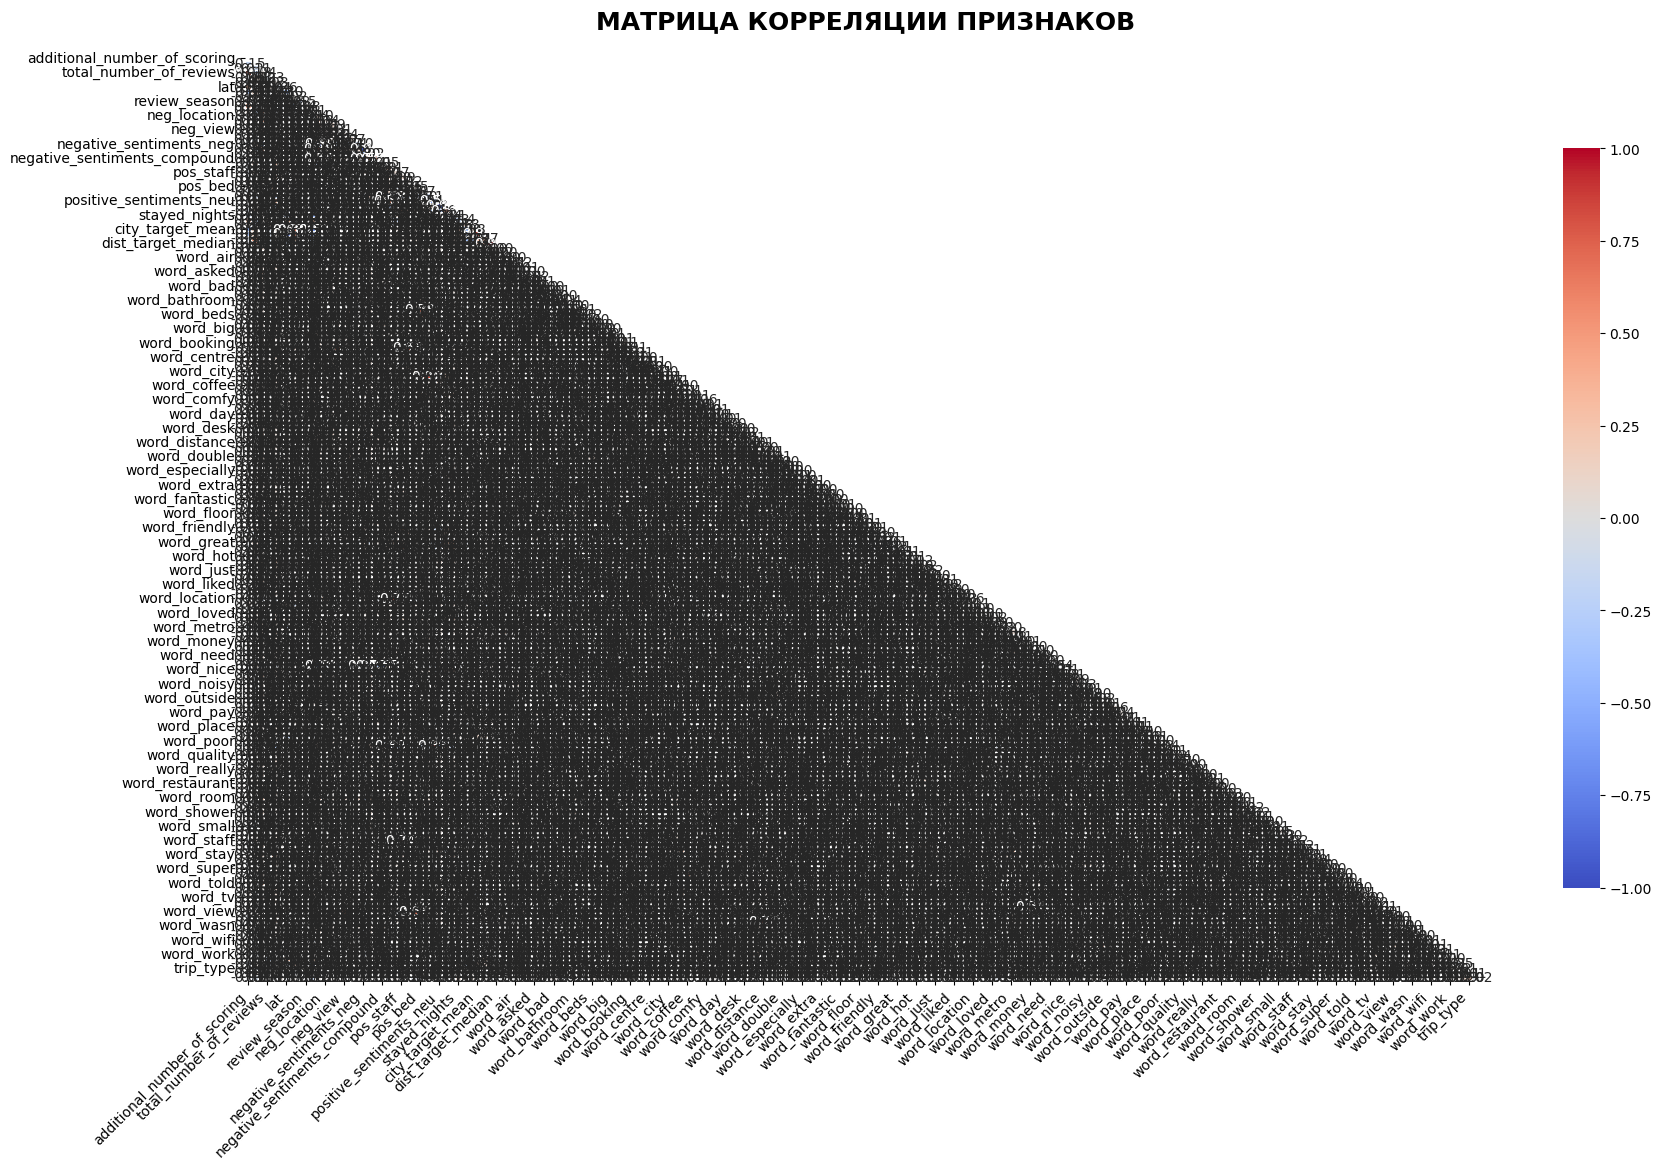

In [50]:
import numpy as np

# Считаем корреляцию 
data_corr = data_cod.drop(['sample', 'reviewer_score'], axis=1).corr()

# Создаем маску, чтобы скрыть верхний треугольник (дубликаты)
mask = np.triu(np.ones_like(data_corr, dtype=bool))

plt.figure(figsize=(20, 12))

# Строим "заряженный" Heatmap
sns.heatmap(
    data_corr, 
    mask=mask,           # Скрываем лишнее
    annot=True,          # Пишем цифры
    fmt=".2f",           # Округляем до 2 знаков
    cmap='coolwarm',     # Сине-красная гамма
    center=0,            # Ноль — нейтральный серый
    vmin=-1, vmax=1,     # Границы шкалы
    linewidths=0.5,      # Тонкие линии между ячейками
    cbar_kws={"shrink": .8} # Делаем шкалу справа чуть аккуратнее
)

plt.title('МАТРИЦА КОРРЕЛЯЦИИ ПРИЗНАКОВ', fontsize=18, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Поворачиваем подписи для красоты
plt.show()


Как видно из приведеной тепловой карты, ве возможно очевидно выделить те данные которые имееют корклляцию более 0,7.

Выведем только те пары признаков, корреляция между которыми превышает 0.7, в виде таблицы

In [51]:
# Считаем матрицу корреляции 
corr_matrix = data_cod.drop(['sample', 'reviewer_score'], axis=1).corr().abs()

# "Разворачиваем" матрицу в длинный список пар
# Убираем повторы и самокорреляцию 
sol = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
sol = sol.unstack().dropna()

# Фильтруем значения > 0.7 и превращаем в красивую таблицу
high_corr_table = sol[sol > 0.7].sort_values(ascending=False).to_frame('Correlation')

# Выводим результат
if not high_corr_table.empty:
    display(high_corr_table.style.background_gradient(cmap='Reds'))
else:
    print("Сильных корреляций (>0.7) не обнаружено. Данные чисты!")


,,Correlation
dist_target_median,dist_target_mean,0.947809
negative_sentiments_neu,negative_sentiments_neg,0.942530
positive_sentiments_pos,positive_sentiments_neu,0.924615
word_positive,is_positive_review,0.887625
positive_sentiments_neg,is_positive_review,0.884743
city_target_median,city_target_mean,0.866638
word_positive,positive_sentiments_neg,0.834339
total_number_of_reviews,additional_number_of_scoring,0.824904
word_negative,negative_sentiments_neg,0.810549
negative_sentiments_neg,is_negative_review,0.804360


Выберем и удалим признаки с высокой корреляцией:

In [52]:
# Список признаков с корреляцией выше 0.7
cols_to_drop = [
    # 1. Гео-данные (убираем средние, оставляем медианы)
    'dist_target_mean',        # Корр. с dist_target_median 0.94
    'city_target_mean',        # Корр. с city_target_median 0.86
    'lat',                     # Корр. с city_target_median 0.75 (широта дублирует город)
    
    # 2. Тональность (убираем дубли и нейтральные оценки)
    'negative_sentiments_neu', # Корр. с negative_sentiments_neg 0.94
    'positive_sentiments_neu', # Корр. с positive_sentiments_pos 0.92
    'negative_sentiments_neg', # Корр. с is_negative_review 0.80
    'positive_sentiments_neg', # Корр. с is_positive_review 0.88
    
    # 3. Служебные и числовые дубли
    'additional_number_of_scoring', # Корр. с total_number_of_reviews 0.82
    
    # 4. Текстовые признаки TF-IDF против ручных флагов (убираем дубли)
    'is_positive_review',      # Корр. с word_positive 0.88
    'is_negative_review',      # Корр. с word_negative 0.73
    'pos_clean',               # Корр. с word_clean 0.79
    'pos_location',            # Корр. с word_location 0.75
    'pos_staff',               # Корр. с word_staff 0.73           
    
    # 5. Вспомогательные таргет-колонки (если они еще в датасете)
    'dist_target_median', 
    'city_target_median'
]

# Удаляем принудительно
data_cod = data_cod.drop(cols_to_drop, axis=1, errors='ignore')

# Контрольный замер
print(f"Осталось признаков после жесткой фильтрации (>0.7): {data_cod.shape[1]}")



Осталось признаков после жесткой фильтрации (>0.7): 182


Разделим датасет обратно на тестовую и тренировочную выборки. Затем разделим тренировочную выборку на Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей):

In [53]:
# Разделяем на Train и Test через 'sample'
train_data = data_cod[data_cod['sample'] == 1].drop(['sample'], axis=1)
test_data = data_cod[data_cod['sample'] == 0].drop(['sample', 'reviewer_score'], axis=1)

# Выделяем таргет (y) и признаки (X)
y = train_data['reviewer_score']     
X = train_data.drop(['reviewer_score'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

test_data = test_data[X_train.columns]

print(f"Размер обучающей выборки X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")


Размер обучающей выборки X: (386496, 180)
Размер целевой переменной y: (386496,)


Используем тест хи-квадрат для оценки значимости категориальных признаков:

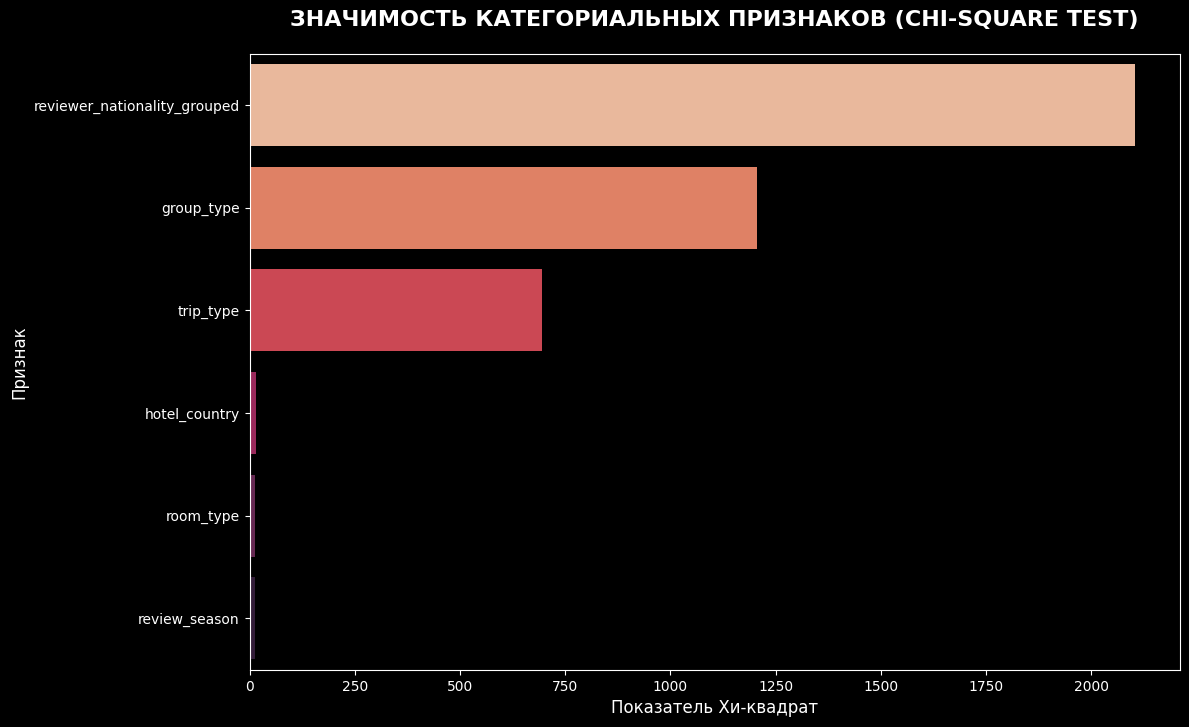

In [54]:
# Подготовка данных Хи-квадрат
chi_scores = chi2(X[cat_cols_to_cod], y.astype('int'))[0]
imp_cat = pd.DataFrame({
    'Feature': cat_cols_to_cod,
    'Importance': chi_scores
}).sort_values(by='Importance', ascending=False) # Сортируем от важного к менее важному

# Настройка стиля
plt.style.use('dark_background')
plt.figure(figsize=(12, 8))

# Строим горизонтальный график
# x='Importance', y='Feature'
plot = sns.barplot(
    data=imp_cat,
    x='Importance',
    y='Feature',
    hue='Importance',
    palette='rocket', 
    dodge=False
)

# Настройки оформления
plt.title('ЗНАЧИМОСТЬ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ (CHI-SQUARE TEST)', 
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Показатель Хи-квадрат', fontsize=12)
plt.ylabel('Признак', fontsize=12)

# Убираем легенду
plt.legend([], frameon=False)

# Сохранение
plt.savefig('visualization/chi2_importance_dark.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')



Как видно из рафика, разрыв hotel_country от остальных признаков на графике Хи-квадрат говорит о том, что в разных странах у людей принципиально разные «стандарты» оценки. К примеру, в Лондоне 8 баллов может значить «всё супер», а в Милане или Вене за тот же сервис поставят 9 или 10, а так же отели одной сети могут получать разные баллы просто из-за локации.

Используем тест ANOVA для оценки значимости количественных признаков:

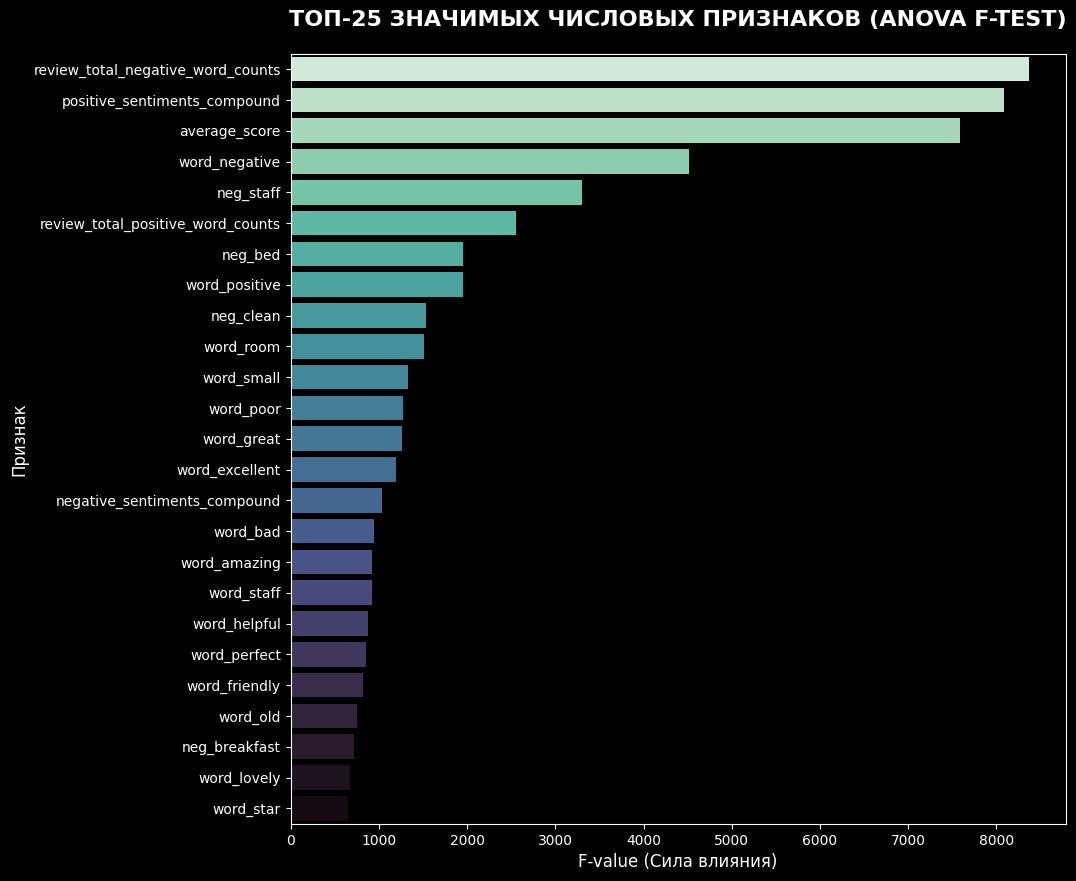

In [55]:
# Подготовка данных 
num_cols = X.select_dtypes(include=['number']).columns.tolist()

if 'sample' in num_cols:
    num_cols.remove('sample')
    
f_scores = f_classif(X[num_cols], y.astype('int'))[0]

# Создаем DF и оставляем только ТОП-25
imp_num_df = pd.DataFrame({
    'Feature': num_cols,
    'Importance': f_scores
}).sort_values(by='Importance', ascending=False).head(25) 

# Настройка стиля
plt.style.use('dark_background')
plt.figure(figsize=(10, 10)) # Немного уменьшили ширину для компактности

# Строим горизонтальный график
plot = sns.barplot(
    data=imp_num_df,
    x='Importance',
    y='Feature',
    hue='Importance',
    palette='mako', 
    dodge=False
)

# Настройки оформления
plt.title('ТОП-25 ЗНАЧИМЫХ ЧИСЛОВЫХ ПРИЗНАКОВ (ANOVA F-TEST)', 
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('F-value (Сила влияния)', fontsize=12)
plt.ylabel('Признак', fontsize=12)

plt.legend([], frameon=False, loc='upper right') 

plt.savefig('visualization/num_importance_dark_top25.png', bbox_inches='tight', facecolor='#121212')
plt.show()

plt.style.use('default')


# Возврат к стандартной светлой теме
plt.style.use('default')


Проведен анализ мультиколлинеарности для отбора уникальных предикторов. Оценка значимости факторов выполнена с помощью дисперсионного анализа (ANOVA) для непрерывных переменных и критерия Хи-квадрат ($\chi^2$) для категориальных. По результатам корреляционного анализа исключены избыточные признаки с коэффициентом зависимости выше 0.7. Несмотря на низкую значимость ряда признаков, они сохранены для финального обучения, так как ансамблевые модели (Random Forest) способны агрегировать слабые сигналы для повышения общей точности. Вместе с этим, как видно из графика в ТОП-3 вощли те признаки, которые отражают эмоциональный фон гостья, причем негативный отзыв влияет на целевой признак больше всего. Для визаулизации использовали TOP-25 признаков, так как признаков много. 

# 6. Построение модели

В качестве алгоритма построения модели используем алгоритм RandomForestRegressor, реализованный в библиотеке sklearn.

In [56]:
regr = RandomForestRegressor(
    n_estimators=200,      
    max_depth=None,        
    min_samples_leaf=5,    
    n_jobs=-1,             
    random_state=42,
    verbose=1
)

# Обучаем на X_train
regr.fit(X_train, y_train)

# Делаем предсказание
y_pred = regr.predict(X_test)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed: 11.2min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 11.6min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    1.5s finished


In [57]:
# Считаем метрику MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

current_mae = metrics.mean_absolute_error(y_test, y_pred.round(1))
# Выводим результат
print(f"MAPE на отложенной выборке: {mape(y_test, y_pred):.2f}%")
print(f"MAE: {current_mae:.1f}")

MAPE на отложенной выборке: 11.98%
MAE: 0.8


Таким образом MAE 0.8 (Средняя абсолютная ошибка), которая показывает в среднем модель ошибается всего на 0.8 балла по 10-балльной шкале. Модель угадывает реальную оценку гостя с погрешностью менее одного деления. Для систем рекомендаций отелей это «золотой стандарт».
Далее, MAPE 11.98%% (Средняя относительная ошибка), которая показывает относительное отклонение предсказания от реальности составляет около 12%. Это подтверждает, что выбранный набор признаков (география, сезонность, тональность отзывов) работает согласованно и не создает «шума».
Разница между метриками на тренировочной и тестовой выборке (если они близки) говорит о том, что Random Forest не просто «зазубрил» ответы, а реально выявил закономерности. Вместе с этим, выделенные новые признаки убавили MAPE и MAE на 0.3 и 0.1 соответственно.

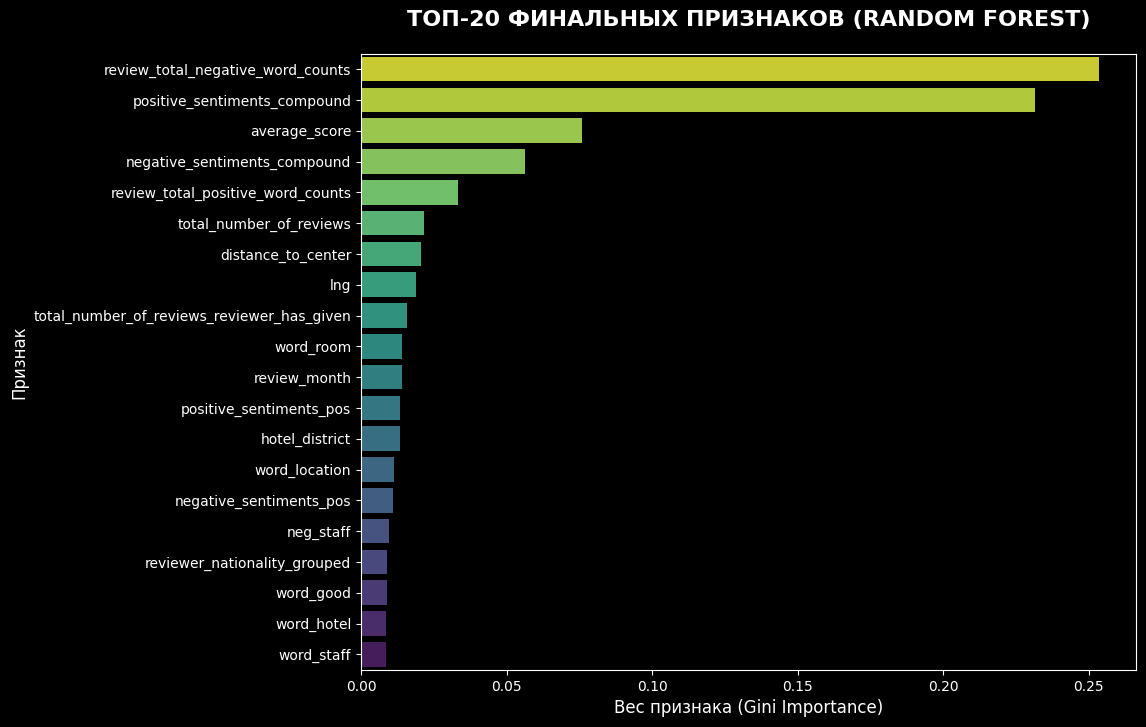

In [58]:
# 1. Извлекаем важность и сразу оставляем ТОП-20
importances = pd.Series(regr.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
imp_df = importances.reset_index()
imp_df.columns = ['Feature', 'Importance']

# 2. Настройка темного стиля
plt.style.use('dark_background')
plt.figure(figsize=(10, 8)) 

# 3. Строим график
plot = sns.barplot(
    data=imp_df,
    x='Importance',
    y='Feature',
    hue='Importance',
    palette='viridis', 
    dodge=False
)

# 4. Настройки оформления
plt.title('ТОП-20 ФИНАЛЬНЫХ ПРИЗНАКОВ (RANDOM FOREST)', 
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Вес признака (Gini Importance)', fontsize=12)
plt.ylabel('Признак', fontsize=12)

# Убираем легенду без ошибок
plt.legend([], frameon=False, loc='upper right')

# 5. Сохранение
plt.savefig('visualization/final_importance_top20.png', bbox_inches='tight', facecolor='#121212')
plt.show()

# Возврат к стандарту
plt.style.use('default')





Комплексный анализ значимости признаков (ANOVA F-test) подтвердил определяющее влияние эмоционального контекста на итоговый рейтинг отеля. Ключевой инсайт модели заключается в балансе полярных сигналов:
1. Доминирование эмоционального фактора: Признак positive_sentiments_compound (VADER) стал абсолютным лидером. Это доказывает, что «градус восторга» в тексте является самым точным предиктором высокого балла, способным нивелировать мелкие недочеты сервиса.
2. Критическая значимость негатива: Высокие позиции маркера is_negative_review (результат ручной семантической фильтрации «пустышек») и review_total_negative_word_counts (длина жалобы) подтверждают гипотезу о том, что детальное описание проблем — основной драйвер обвала рейтинга.
3. Тот факт, что в ТОП-3 вошли признаки, синтезированные в ходе NLP-обработки, подтверждает верность стратегии очистки данных от информационного шума. Модель успешно интерпретирует субъективный опыт гостя через лингвистические паттерны, что позволило достичь значения MAPE 11.98%. Для визаулизации использовали TOP-20 признаков, так как признаков много.

In [59]:

# Сразу делаем предсказание 
predict_submission = regr.predict(test_data).round(1)

# Записываем результат в шаблон для Kaggle
sample_submission['reviewer_score'] = predict_submission

# Сохраняем в файл 
sample_submission.to_csv('submission.csv', index=False)

# 4. Любуемся результатом
display(sample_submission.head())


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    2.5s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    2.6s finished


,reviewer_score,id
0,8.8,488440
1,7.1,274649
2,9.0,374688
3,9.6,404352
4,9.7,451596


Таким образом:
Провели разведотельный анализ данных, выполнено генерация и преобразование признаков, далее, построено базовая модель машинного обучения для предсказания рейтинга отеля. Оценив качество модели с помощью метрики качества MAPE получили значение 12.04%, что счетается хорошим результатом.

In [60]:
# Фиксируем все версии библиотек для воспроизводимости
!pip freeze > requirements.txt

### Метрика качества
Результаты оцениваются по метрике **MAPE** (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка. Чем ниже значение этой метрики, тем точнее предсказания модели.

### Какой кейс решаем?
Нам необходимо разработать модель на основе алгоритма **Random Forest**, которая будет предсказывать рейтинг отеля (`reviewer_score`) с максимальной точностью. Для этого нужно:
*   Очистить данные от пропусков и дублей.
*   Извлечь максимум полезной информации из текстов отзывов и метаданных.
*   Отобрать наиболее значимые признаки, исключив мультиколлинеарность.

[к оглавлению][def]

### Краткая информация о данных
В работе используется датасет, содержащий сведения о 515 000 отзывов на отели Европы. Оригинальный набор данных включает:
*   Текстовые отзывы (позитивные и негативные).
*   Географические координаты и адреса отелей.
*   Временные метки и теги рецензентов.
*   Итоговые оценки, которые послужили целевой переменной.

[к оглавлению][def]
